# 🌾 Chapter 2: Data Collection, Exploration & Preprocessing
## Project: Crop Yield Prediction for Bangladesh Agriculture

---
> **Authors:** Group Project  
> **Dataset:** Bangladesh Agricultural Crop Yield Dataset  
> **Objective:** Predict crop yield (tonnes/hectare) from climatic, soil, and remote-sensing features

---

## 📦 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## 📂 1. Data Collection

### 1.1 Data Source

| Item | Detail |
|------|--------|
| **Source** | Kaggle — Bangladesh Agricultural Crop Yield Dataset |
| **Domain** | Agriculture / Precision Farming |
| **Geography** | 64 Districts of Bangladesh |
| **Time scope** | Multi-season (Rabi, Kharif 1, Kharif 2) |
| **Dataset file** | `Agri_Data_Cleaned.csv` — 4,178 cleaned records, 51 features |

### 1.2 Data Collection Methodology

The dataset integrates **five** distinct data collection modalities:

1. **Field surveys & government records** — Harvested area (ha), production (tonnes), crop calendar (transplant/growth/harvest months), district names collected by the Bangladesh Bureau of Statistics (BBS).
2. **Meteorological station data** — Temperature (avg/max/min), relative humidity (avg/max/min), rainfall (mm), heat-stress days, and wind speed from Bangladesh Meteorological Department (BMD) ground stations.
3. **Satellite remote sensing (NASA/ESA)** — NDVI (Normalized Difference Vegetation Index) time-series statistics, EVI (Enhanced Vegetation Index), LAI (Leaf Area Index), FPAR, and LST (Land Surface Temperature) derived from MODIS and Sentinel-2 imagery.
4. **Soil characterization** — pH, organic carbon (%), nitrogen (%), clay/sand/silt proportions (%), bulk density (g/cm³), C:N ratio, salinity index, and soil texture class from the Soil Resources Development Institute (SRDI) and FAO SoilGrids.
5. **Soil moisture products** — Surface and root-zone soil moisture (m³/m³) and derived indices from NASA SMAP satellite and ERA5-Land reanalysis.

### 1.3 Data Dictionary


In [2]:
data_dict = {
    'Variable': [
        'Area','District','Season','Avg Temp','Avg Humidity','Crop Name',
        'Transplant','Growth','Harvest','Production',
        'Max Temp','Min Temp','Max Relative Humidity','Min Relative Humidity',
        'EVI','LAI','FPAR','Soil_Moisture_mm',
        'NDVI_Season_Mean','NDVI_Season_Max','NDVI_Season_Min',
        'NDVI_Season_Std','NDVI_Season_Range','NDVI_Season_CV',
        'Avg_Salinity_Index','pH','Organic_Carbon','Nitrogen',
        'Clay','Sand','Silt','Bulk_Density','CN_Ratio',
        'pH_Suitability','Dominant_Soil_Texture',
        'sm_surface','sm_rootzone','Rootzone_Surface_Diff','Moisture_Ratio',
        'Water_Availability_Cat','Rainfall',
        'Heat_Stress_Days','Wind_Mean','Wind_Max','Rain_Temp_Ratio',
        'Extreme_Heat_Risk','Is_Extreme_Heat','LST_C',
        'is_extreme_Heat_Stress_Days','is_extreme_Wind_Max',
        'Yield'
    ],
    'Type': [
        'float','str','str','float','float','str',
        'str','str','str','float',
        'float','float','float','float',
        'float','float','float','float',
        'float','float','float',
        'float','float','float',
        'float','float','float','float',
        'float','float','float','float','float',
        'str','str',
        'float','float','float','float',
        'str','float',
        'float','float','float','float',
        'str','int','float',
        'int','int',
        'float'
    ],
    'Unit': [
        'hectares','—','—','°C','%','—',
        'month','period','month','tonnes',
        '°C','°C','%','%',
        'index (0-1)','m²/m²','fraction','mm',
        'index','index','index',
        'index','index','index',
        'index','pH units','%','%',
        '%','%','%','g/cm³','ratio',
        'category','category',
        'm³/m³','m³/m³','m³/m³','ratio',
        'category','mm',
        'days','m/s','m/s','mm/°C',
        'category','binary','°C',
        'binary','binary',
        'tonnes/hectare'
    ],
    'Description': [
        'Harvested crop area in hectares','Administrative district name (64 districts)','Growing season (Rabi / Kharif 1 / Kharif 2)','Seasonal average temperature','Seasonal average relative humidity','Name of the cultivated crop (72 unique crops)',
        'Month when transplanting/sowing starts','Growth period description','Harvest month or period','Total production in metric tonnes',
        'Maximum temperature recorded during season','Minimum temperature recorded during season','Maximum relative humidity during season','Minimum relative humidity during season',
        'Enhanced Vegetation Index from MODIS satellite','Leaf Area Index — canopy size indicator','Fraction of Photosynthetically Active Radiation absorbed','Total soil moisture in millimetres',
        'Mean NDVI over full season','Peak NDVI value during season','Lowest NDVI value during season',
        'Standard deviation of NDVI time-series','Max minus Min NDVI (season range)','Coefficient of Variation of NDVI',
        'Average soil electrical conductivity salinity index','Soil pH value','Percentage soil organic carbon','Percentage total nitrogen in soil',
        'Percentage clay content in soil','Percentage sand content in soil','Percentage silt content in soil','Soil bulk density (g/cm³)','Carbon-to-Nitrogen ratio',
        'pH suitability class (Optimal / Acidic)','Dominant soil texture class (Loamy / Silty / Clayey)',
        'Surface layer soil moisture (m³/m³)','Root-zone layer soil moisture (m³/m³)','Difference: rootzone − surface moisture','Ratio: rootzone / surface moisture',
        'Water availability category (Optimal / Moderate)','Total seasonal rainfall in millimetres',
        'Number of heat-stress days (Tmax > 35°C)','Mean wind speed (m/s)','Maximum wind gust speed (m/s)','Rainfall-to-Temperature ratio',
        'Heat risk classification (Low / Moderate / High Risk)','Binary flag: 1 = extreme heat event occurred','Land Surface Temperature in Celsius from MODIS',
        'Binary: 1 = extreme heat stress days detected','Binary: 1 = extreme wind event detected',
        '🎯 TARGET — Yield in tonnes per hectare (Production / Area)'
    ]
}

dd_df = pd.DataFrame(data_dict)
print(f'📖 Data Dictionary — {len(dd_df)} variables documented')
dd_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#2E7D32'), ('color', 'white'), ('font-weight', 'bold')]}]
)

📖 Data Dictionary — 51 variables documented


,Variable,Type,Unit,Description
0,Area,float,hectares,Harvested crop area in hectares
1,District,str,—,Administrative district name (64 districts)
2,Season,str,—,Growing season (Rabi / Kharif 1 / Kharif 2)
3,Avg Temp,float,°C,Seasonal average temperature
4,Avg Humidity,float,%,Seasonal average relative humidity
5,Crop Name,str,—,Name of the cultivated crop (72 unique crops)
6,Transplant,str,month,Month when transplanting/sowing starts
7,Growth,str,period,Growth period description
8,Harvest,str,month,Harvest month or period
9,Production,float,tonnes,Total production in metric tonnes


---
## 📊 2. Exploratory Data Analysis (EDA)

### 2.1 Load Data

In [3]:
df = pd.read_csv('Agri_Data_Cleaned.csv')

print('=' * 55)
print(f"  DATASET  |  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print('=' * 55)
print(f"  Crops    : {df['Crop Name'].nunique()} unique crops")
print(f"  Districts: {df['District'].nunique()} districts")
print(f"  Seasons  : {df['Season'].nunique()} seasons → {df['Season'].unique().tolist()}")
df.head(5)


  DATASET  |  Rows: 4,178  |  Columns: 51
  Crops    : 72 unique crops
  Districts: 64 districts
  Seasons  : 3 seasons → ['Rabi', 'Kharif 1', 'Kharif 2']


,Area,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,Max Temp,Min Temp,Max Relative Humidity,Min Relative Humidity,EVI,LAI,FPAR,Soil_Moisture_mm,NDVI_Season_Mean,NDVI_Season_Max,NDVI_Season_Min,NDVI_Season_Std,NDVI_Season_Range,NDVI_Season_CV,Avg_Salinity_Index,pH,Organic_Carbon,Nitrogen,Clay,Sand,Silt,Bulk_Density,CN_Ratio,pH_Suitability,Dominant_Soil_Texture,sm_surface,sm_rootzone,Rootzone_Surface_Diff,Moisture_Ratio,Water_Availability_Cat,Rainfall,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat,LST_C,is_extreme_Heat_Stress_Days,is_extreme_Wind_Max,Yield
0,259,Bagerhat,Rabi,17.7500,55.0000,Wheat,December,Jan To March,April,200.0000,20,15.5000,65,50,0.3116,2.4184,0.6315,12.0780,0.5118,0.5712,0.4541,0.0511,0.1171,0.0999,560.4940,5.7300,33.0400,3.2150,28.2500,22.2300,49.5200,1.2300,8.7300,Optimal,Loamy,0.2675,0.3651,0.0976,1.4035,Optimal,220.4300,0.0000,1.4529,4.3300,11.2300,Low Risk,0,24.1445,0,0,0.7722
1,421,Bagerhat,Rabi,20.5000,60.0000,Maize 2,December,Jan To March,April,946.0000,27,14.0000,70,50,0.3116,2.4184,0.6315,12.0780,0.5118,0.5712,0.4541,0.0511,0.1171,0.0999,560.4940,5.7300,33.0400,3.2150,28.2500,22.2300,49.5200,1.2300,8.7300,Optimal,Loamy,0.2675,0.3651,0.0976,1.4035,Optimal,220.4300,0.0000,1.4529,4.3300,11.2300,Low Risk,0,24.1445,0,0,2.2470
2,145439,Bagerhat,Rabi,26.0000,72.5000,Boro,November,Dec To March,April,268754.0000,40,12.0000,85,60,0.3116,2.4184,0.6315,12.0780,0.5118,0.5712,0.4541,0.0511,0.1171,0.0999,560.4940,5.7300,33.0400,3.2150,28.2500,22.2300,49.5200,1.2300,8.7300,Optimal,Loamy,0.2935,0.3855,0.0920,1.3611,Optimal,220.4300,0.0000,1.4529,4.3300,11.2300,Low Risk,0,24.1445,0,0,1.8479
3,627,Bagerhat,Rabi,20.5000,80.0000,Sweet Potato,November,Dec To March,April,2200.0000,24,17.0000,90,70,0.3116,2.4184,0.6315,12.0780,0.5118,0.5712,0.4541,0.0511,0.1171,0.0999,560.4940,5.7300,33.0400,3.2150,28.2500,22.2300,49.5200,1.2300,8.7300,Optimal,Loamy,0.2935,0.3855,0.0920,1.3611,Optimal,220.4300,0.0000,1.4529,4.3300,11.2300,Low Risk,0,24.1445,0,0,3.5088
4,383,Bagerhat,Kharif 1,31.5000,70.0000,Mango,April,April To May,April To June,1913.0000,36,27.0000,90,50,0.3082,1.8113,0.4169,14.7710,0.2671,0.3077,0.2094,0.0420,0.0983,0.1570,883.0219,5.7300,33.0400,3.2150,28.2500,22.2300,49.5200,1.2300,8.7300,Optimal,Loamy,0.2769,0.3438,0.0669,1.3033,Optimal,656.3300,42.5000,2.4819,5.8600,22.7300,High Risk,1,28.4320,1,0,4.9948


### 2.2 Dataset Overview

In [4]:
# Column types summary
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()

print(f"📌 Total features   : {df.shape[1]} (including target)")
print(f"📌 Numerical cols   : {len(num_cols)}")
print(f"📌 Categorical cols : {len(cat_cols)}")
print(f"📌 Target variable  : Yield (tonnes/hectare)")
print()
print("Numerical columns:")
print(num_cols)
print()
print("Categorical columns:")
print(cat_cols)


📌 Total features   : 51 (including target)
📌 Numerical cols   : 41
📌 Categorical cols : 10
📌 Target variable  : Yield (tonnes/hectare)

Numerical columns:
['Area', 'Avg Temp', 'Avg Humidity', 'Production', 'Max Temp', 'Min Temp', 'Max Relative Humidity', 'Min Relative Humidity', 'EVI', 'LAI', 'FPAR', 'Soil_Moisture_mm', 'NDVI_Season_Mean', 'NDVI_Season_Max', 'NDVI_Season_Min', 'NDVI_Season_Std', 'NDVI_Season_Range', 'NDVI_Season_CV', 'Avg_Salinity_Index', 'pH', 'Organic_Carbon', 'Nitrogen', 'Clay', 'Sand', 'Silt', 'Bulk_Density', 'CN_Ratio', 'sm_surface', 'sm_rootzone', 'Rootzone_Surface_Diff', 'Moisture_Ratio', 'Rainfall', 'Heat_Stress_Days', 'Wind_Mean', 'Wind_Max', 'Rain_Temp_Ratio', 'Is_Extreme_Heat', 'LST_C', 'is_extreme_Heat_Stress_Days', 'is_extreme_Wind_Max', 'Yield']

Categorical columns:
['District', 'Season', 'Crop Name', 'Transplant', 'Growth', 'Harvest', 'pH_Suitability', 'Dominant_Soil_Texture', 'Water_Availability_Cat', 'Extreme_Heat_Risk']


In [5]:
# Data types overview
dtype_df = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Unique Values': [df[c].nunique() for c in df.columns],
    'Sample Value': [str(df[c].iloc[0])[:40] for c in df.columns]
})
print('📋 Complete Column Info:')
dtype_df


📋 Complete Column Info:


,Column,Dtype,Non-Null Count,Null Count,Null %,Unique Values,Sample Value
0,Area,int64,4178,0,0.0000,1771,259
1,District,object,4178,0,0.0000,64,Bagerhat
2,Season,object,4178,0,0.0000,3,Rabi
3,Avg Temp,float64,4178,0,0.0000,30,17.75
4,Avg Humidity,float64,4178,0,0.0000,17,55.0
5,Crop Name,object,4178,0,0.0000,72,Wheat
6,Transplant,object,4178,0,0.0000,12,December
7,Growth,object,4178,0,0.0000,31,Jan To March
8,Harvest,object,4178,0,0.0000,34,April
9,Production,float64,4178,0,0.0000,2570,200.0


### 2.3 Missing Value Analysis

In [6]:
missing = df.isnull().sum()
total_missing = missing.sum()

print('=' * 50)
print(f'  Total rows    : {len(df):,}')
print(f'  Total columns : {df.shape[1]}')
print(f'  Missing values: {total_missing}')
print('=' * 50)

if total_missing == 0:
    print('\n✅ EXCELLENT: Dataset is COMPLETE — No missing values detected!')
    print('   → No imputation or missing-value treatment is required.')
else:
    print('\n⚠️  Missing values found:')
    print(missing[missing > 0])


  Total rows    : 4,178
  Total columns : 51
  Missing values: 0

✅ EXCELLENT: Dataset is COMPLETE — No missing values detected!
   → No imputation or missing-value treatment is required.


### 2.4 Basic Distribution Statistics — Numerical Features

In [7]:
desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew().round(4)
desc['kurtosis'] = df[num_cols].kurtosis().round(4)
desc = desc[['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis']]
desc.columns = ['Count','Mean','Std','Min','Q1','Median','Q3','Max','Skewness','Kurtosis']
print('📊 Descriptive Statistics (Numerical Features):')
desc.style.background_gradient(subset=['Skewness','Kurtosis'], cmap='RdYlGn_r').format('{:.3f}')


📊 Descriptive Statistics (Numerical Features):


,Count,Mean,Std,Min,Q1,Median,Q3,Max,Skewness,Kurtosis
Area,4178.000,8916.956,44187.096,1.000,106.000,335.500,949.750,663734.000,7.940,76.066
Avg Temp,4178.000,23.961,4.690,11.500,20.000,25.000,27.500,34.500,-0.185,-0.402
Avg Humidity,4178.000,72.614,9.168,48.750,67.500,72.500,80.000,90.000,-0.654,0.423
Production,4178.000,15841.236,68746.024,1.000,233.000,904.000,3389.750,1077242.000,7.491,69.392
Max Temp,4178.000,30.868,5.896,15.000,27.000,30.000,35.000,47.000,-0.066,-0.046
Min Temp,4178.000,17.054,5.408,5.000,14.000,18.000,20.000,27.000,-0.153,-0.631
Max Relative Humidity,4178.000,82.890,8.548,65.000,80.000,85.000,90.000,100.000,-0.515,-0.527
Min Relative Humidity,4178.000,63.017,10.104,45.000,60.000,60.000,70.000,85.000,-0.015,-0.631
EVI,4178.000,0.344,0.063,0.187,0.306,0.332,0.386,0.506,0.242,0.189
LAI,4178.000,1.372,0.450,0.710,1.031,1.290,1.586,2.418,0.941,0.102


### 2.5 Categorical Feature Overview

In [8]:
for col in cat_cols:
    vc = df[col].value_counts()
    print(f"\n📌 {col} — {df[col].nunique()} unique values")
    if df[col].nunique() <= 10:
        for val, cnt in vc.items():
            print(f"   {val:35s}: {cnt:5d} ({cnt/len(df)*100:.1f}%)")
    else:
        print(f"   Top 5: {list(vc.head(5).index)}")
        print(f"   Full list ({df[col].nunique()} items): {sorted(df[col].unique()[:10])} ...")



📌 District — 64 unique values
   Top 5: ['Thakurgaon', 'Chuadanga', 'Dinajpur', 'Jhenaidah', 'Jamalpur']
   Full list (64 items): ['Bagerhat', 'Bandarban', 'Barguna', 'Barishal', 'Bhola', 'Bogura', 'Brahmanbaria', 'Chandpur', 'Chapai Nawabganj', 'Chattogram'] ...

📌 Season — 3 unique values
   Kharif 2                           :  1569 (37.6%)
   Kharif 1                           :  1421 (34.0%)
   Rabi                               :  1188 (28.4%)

📌 Crop Name — 72 unique values
   Top 5: ['Beans', 'Danta Shak', 'Cucumber', 'Lal Shak', 'Laushak']
   Full list (72 items): ['Aus', 'Boro', 'Jack Fruit', 'Karala', 'Maize 2', 'Mango', 'Ripe Papaya', 'Sugarcane', 'Sweet Potato', 'Wheat'] ...

📌 Transplant — 12 unique values
   Top 5: ['April', 'October', 'September', 'June', 'March']
   Full list (12 items): ['April', 'August', 'December', 'February', 'June', 'March', 'May', 'November', 'October', 'September'] ...

📌 Growth — 31 unique values
   Top 5: ['April To May', 'Nov To March', 'Ju

### 2.6 🎯 Target Variable — Yield Analysis

📊 TARGET VARIABLE: Yield (tonnes/hectare)
  Count     : 4,178
  Mean      : 4.1786 t/ha
  Median    : 2.5150 t/ha
  Std Dev   : 5.7743
  Min       : 0.0139 t/ha
  Max       : 98.9907 t/ha
  Skewness  : 5.1751  (Right-skewed ➡️)
  Kurtosis  : 47.7938
  IQR       : 3.3759
  CV (%)    : 138.19%

  Outliers (IQR method): 381 (9.12%)


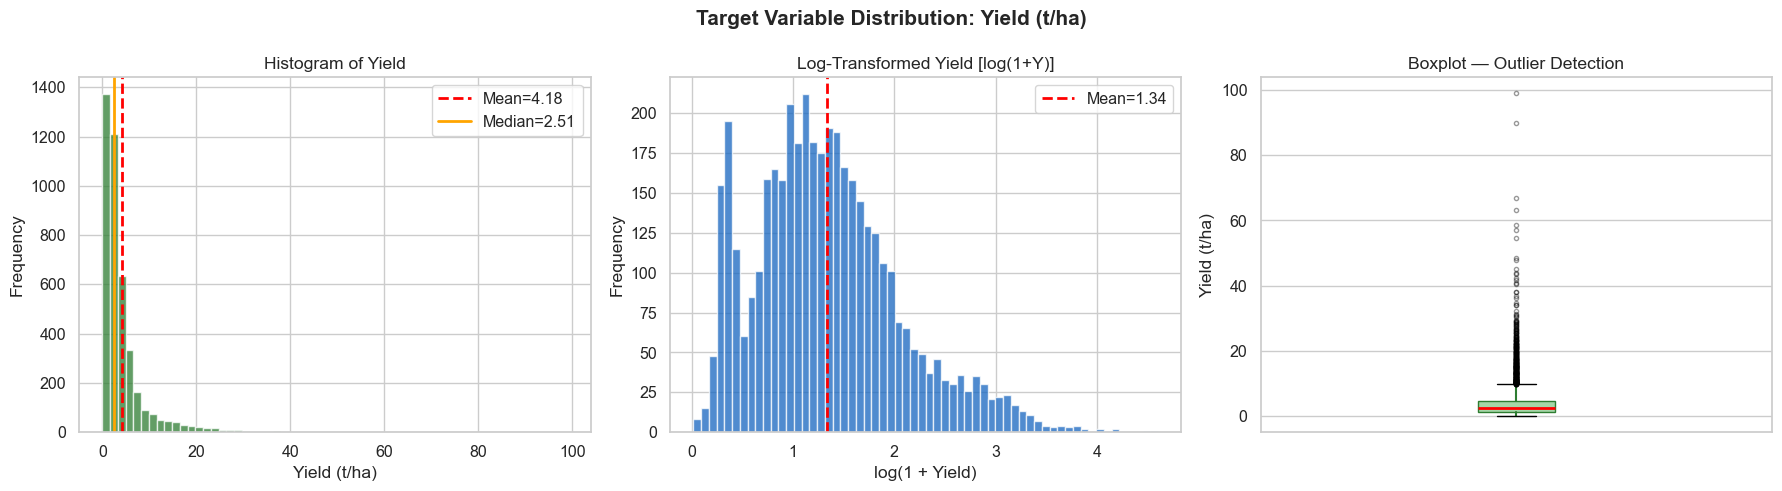


🔍 Observation: Yield is highly right-skewed. Log transformation produces a near-normal distribution.


In [9]:
y = df['Yield']

print('📊 TARGET VARIABLE: Yield (tonnes/hectare)')
print('=' * 50)
print(f"  Count     : {y.count():,}")
print(f"  Mean      : {y.mean():.4f} t/ha")
print(f"  Median    : {y.median():.4f} t/ha")
print(f"  Std Dev   : {y.std():.4f}")
print(f"  Min       : {y.min():.4f} t/ha")
print(f"  Max       : {y.max():.4f} t/ha")
print(f"  Skewness  : {y.skew():.4f}  {'(Right-skewed ➡️)' if y.skew()>0.5 else '(Approx. symmetric)'}")
print(f"  Kurtosis  : {y.kurtosis():.4f}")
print(f"  IQR       : {y.quantile(0.75) - y.quantile(0.25):.4f}")
print(f"  CV (%)    : {y.std()/y.mean()*100:.2f}%")

Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
outliers = ((y < Q1 - 1.5*IQR) | (y > Q3 + 1.5*IQR)).sum()
print(f"\n  Outliers (IQR method): {outliers} ({outliers/len(y)*100:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable Distribution: Yield (t/ha)', fontsize=15, fontweight='bold')

axes[0].hist(y, bins=60, color='#2E7D32', alpha=0.75, edgecolor='white')
axes[0].axvline(y.mean(),   color='red',    linestyle='--', linewidth=2, label=f'Mean={y.mean():.2f}')
axes[0].axvline(y.median(), color='orange', linestyle='-',  linewidth=2, label=f'Median={y.median():.2f}')
axes[0].set_title('Histogram of Yield')
axes[0].set_xlabel('Yield (t/ha)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

log_y = np.log1p(y)
axes[1].hist(log_y, bins=60, color='#1565C0', alpha=0.75, edgecolor='white')
axes[1].axvline(log_y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={log_y.mean():.2f}')
axes[1].set_title('Log-Transformed Yield [log(1+Y)]')
axes[1].set_xlabel('log(1 + Yield)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

axes[2].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#A5D6A7', color='#2E7D32'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='#2E7D32', linewidth=1.5),
                flierprops=dict(marker='o', color='tomato', alpha=0.4, markersize=3))
axes[2].set_title('Boxplot — Outlier Detection')
axes[2].set_ylabel('Yield (t/ha)')
axes[2].set_xticks([])

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n🔍 Observation: Yield is highly right-skewed. Log transformation produces a near-normal distribution.')


### 2.7 Yield by Crop Name — Top/Bottom Analysis

In [10]:
crop_yield = df.groupby('Crop Name')['Yield'].agg(['mean','median','std','count']).round(3)
crop_yield.columns = ['Mean Yield','Median Yield','Std Dev','Record Count']
crop_yield = crop_yield.sort_values('Mean Yield', ascending=False)

print('🌾 Crop Yield Statistics (sorted by Mean Yield):')
crop_yield.style.background_gradient(subset=['Mean Yield'], cmap='Greens').format({'Mean Yield':'{:.2f}','Median Yield':'{:.2f}','Std Dev':'{:.2f}'})


🌾 Crop Yield Statistics (sorted by Mean Yield):


,Mean Yield,Median Yield,Std Dev,Record Count
Crop Name,,,,
Jack Fruit,17.48,15.23,13.84,64
Ripe Papaya,16.06,14.71,8.54,64
Green Papaya,15.04,12.97,13.21,64
Green Coconut,13.77,10.28,14.15,64
Sugarcane,13.77,14.19,5.79,64
Green Palmyra,10.50,6.83,9.88,62
Palmyra Palm,9.98,7.67,8.49,45
Jambura,7.74,6.46,5.37,64
Mango,7.25,6.00,6.41,64


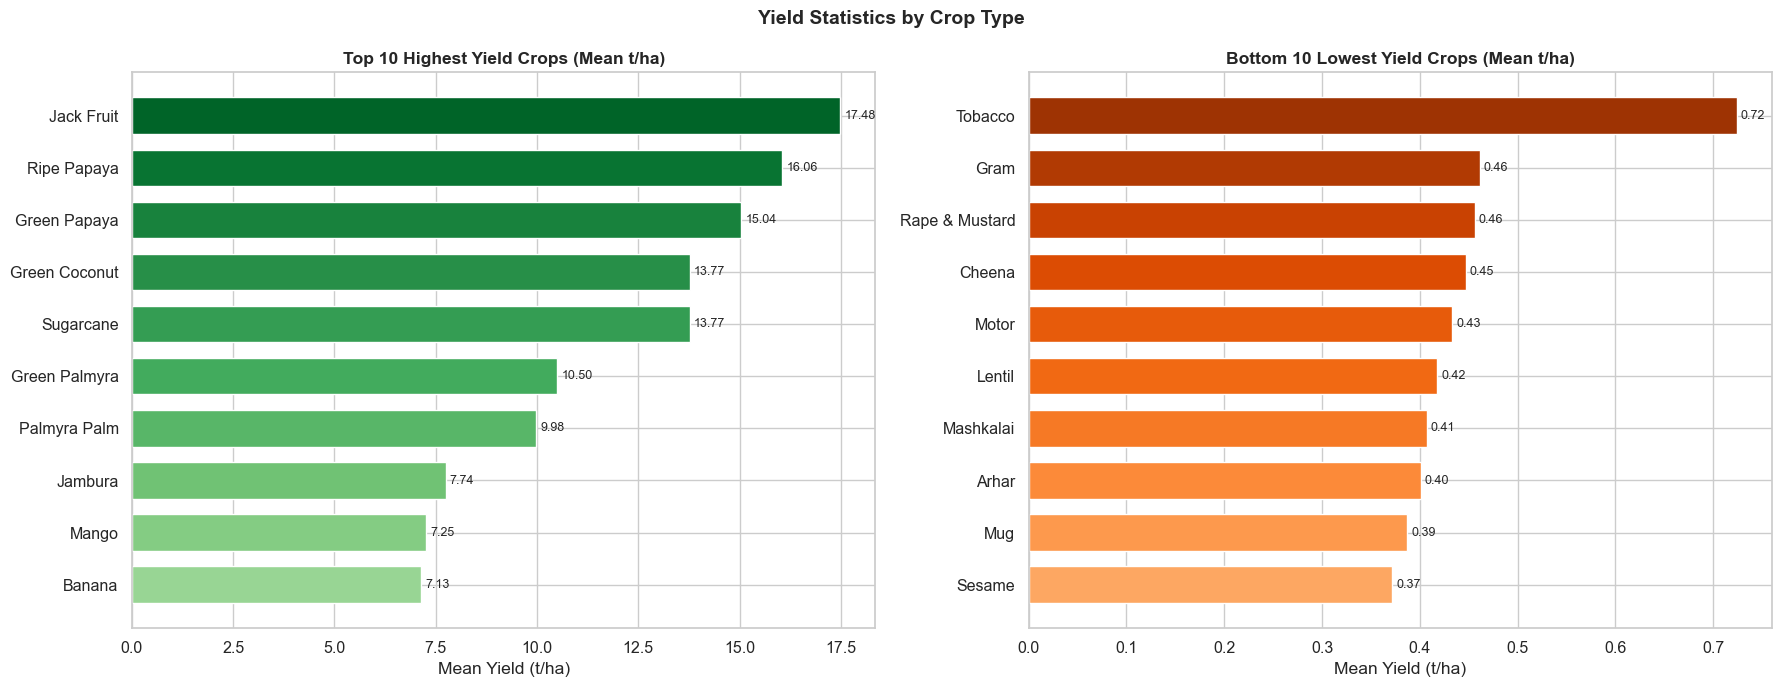

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Yield Statistics by Crop Type', fontsize=14, fontweight='bold')

top10 = crop_yield.head(10)
bot10 = crop_yield.tail(10)

colors_top = plt.cm.Greens(np.linspace(0.4, 0.9, 10))[::-1]
bars = axes[0].barh(top10.index, top10['Mean Yield'], color=colors_top, edgecolor='white', height=0.7)
axes[0].bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
axes[0].set_title('Top 10 Highest Yield Crops (Mean t/ha)', fontweight='bold')
axes[0].set_xlabel('Mean Yield (t/ha)')
axes[0].invert_yaxis()

colors_bot = plt.cm.Oranges(np.linspace(0.4, 0.9, 10))[::-1]
bars2 = axes[1].barh(bot10.index, bot10['Mean Yield'], color=colors_bot, edgecolor='white', height=0.7)
axes[1].bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)
axes[1].set_title('Bottom 10 Lowest Yield Crops (Mean t/ha)', fontweight='bold')
axes[1].set_xlabel('Mean Yield (t/ha)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('yield_by_crop.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.8 Yield by Season

🌤️  Yield by Season:
           Mean  Median    Std  Count
Season                               
Kharif 1 5.8750  3.0660 7.9050   1421
Kharif 2 3.5630  2.3800 4.5540   1569
Rabi     2.9630  2.1370 3.1240   1188


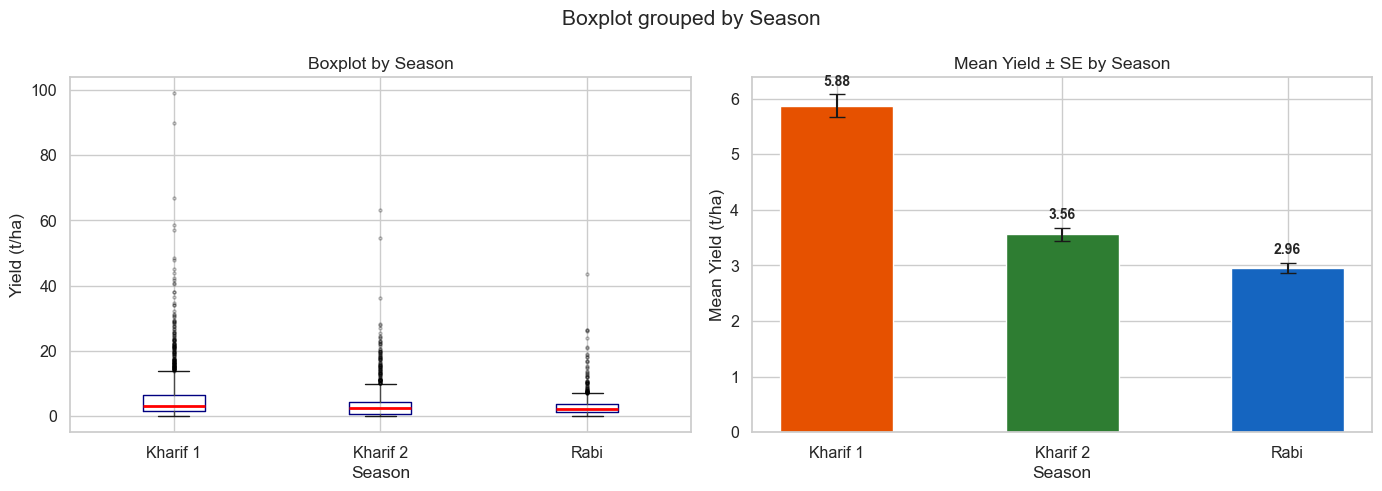

In [12]:
season_stats = df.groupby('Season')['Yield'].agg(['mean','median','std','count'])
season_stats.columns = ['Mean','Median','Std','Count']
print('🌤️  Yield by Season:')
print(season_stats.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Yield Distribution by Season', fontsize=13, fontweight='bold')

palette = {'Rabi': '#1565C0', 'Kharif 1': '#E65100', 'Kharif 2': '#2E7D32'}

df.boxplot(column='Yield', by='Season', ax=axes[0],
           boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_title('Boxplot by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Yield (t/ha)')

colors = [palette.get(s, 'gray') for s in season_stats.index]
bars = axes[1].bar(season_stats.index, season_stats['Mean'], color=colors,
                   edgecolor='white', width=0.5,
                   yerr=season_stats['Std']/np.sqrt(season_stats['Count']),
                   capsize=6, error_kw={'elinewidth': 1.5})
axes[1].bar_label(bars, fmt='%.2f', padding=4, fontsize=10, fontweight='bold')
axes[1].set_title('Mean Yield ± SE by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Mean Yield (t/ha)')

plt.tight_layout()
plt.savefig('yield_by_season.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.9 Correlation Analysis — Numerical Features

📊 Top 15 Features Most Correlated with Yield:
Heat_Stress_Days               0.2149
Avg Temp                       0.2047
Is_Extreme_Heat                0.1981
Min Temp                       0.1821
FPAR                          -0.1636
LST_C                          0.1620
Avg_Salinity_Index             0.1597
Max Temp                       0.1586
is_extreme_Heat_Stress_Days    0.1576
NDVI_Season_Mean              -0.1563
NDVI_Season_Max               -0.1476
Max Relative Humidity          0.1295
Wind_Mean                      0.1212
NDVI_Season_Min               -0.1095
LAI                           -0.0948


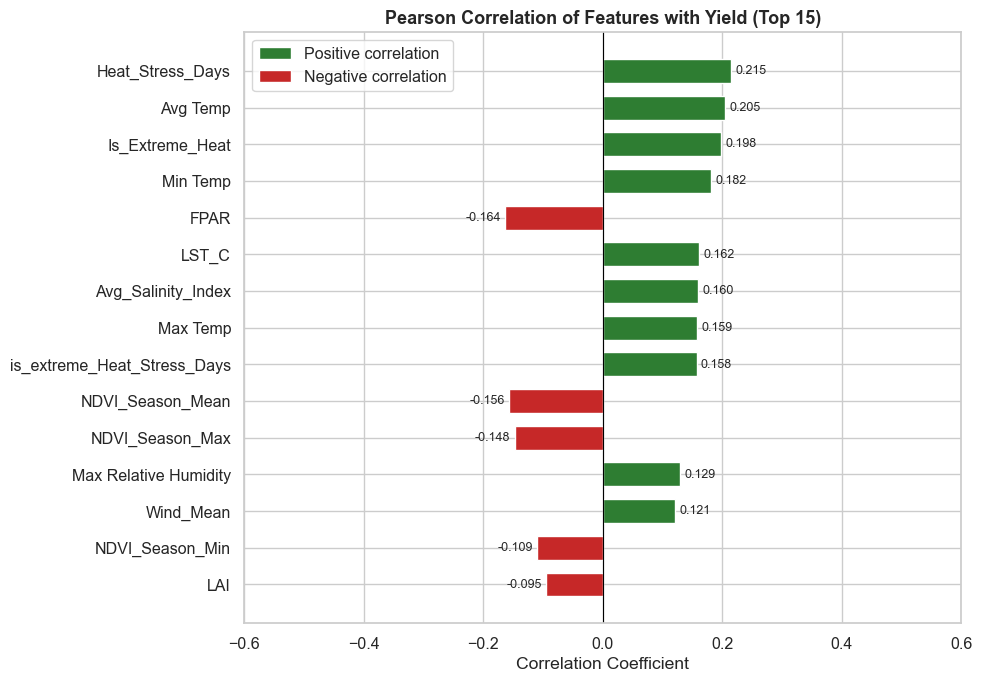

In [13]:
corr_matrix = df[num_cols].corr()
yield_corr  = corr_matrix['Yield'].drop('Yield').sort_values(key=abs, ascending=False)

print('📊 Top 15 Features Most Correlated with Yield:')
print(yield_corr.head(15).to_string())

top15 = yield_corr.head(15)
colors = ['#2E7D32' if v > 0 else '#C62828' for v in top15.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_title('Pearson Correlation of Features with Yield (Top 15)', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.set_xlim(-0.6, 0.6)
green_patch = plt.Rectangle((0,0),1,1, fc='#2E7D32')
red_patch   = plt.Rectangle((0,0),1,1, fc='#C62828')
ax.legend([green_patch, red_patch], ['Positive correlation', 'Negative correlation'])
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


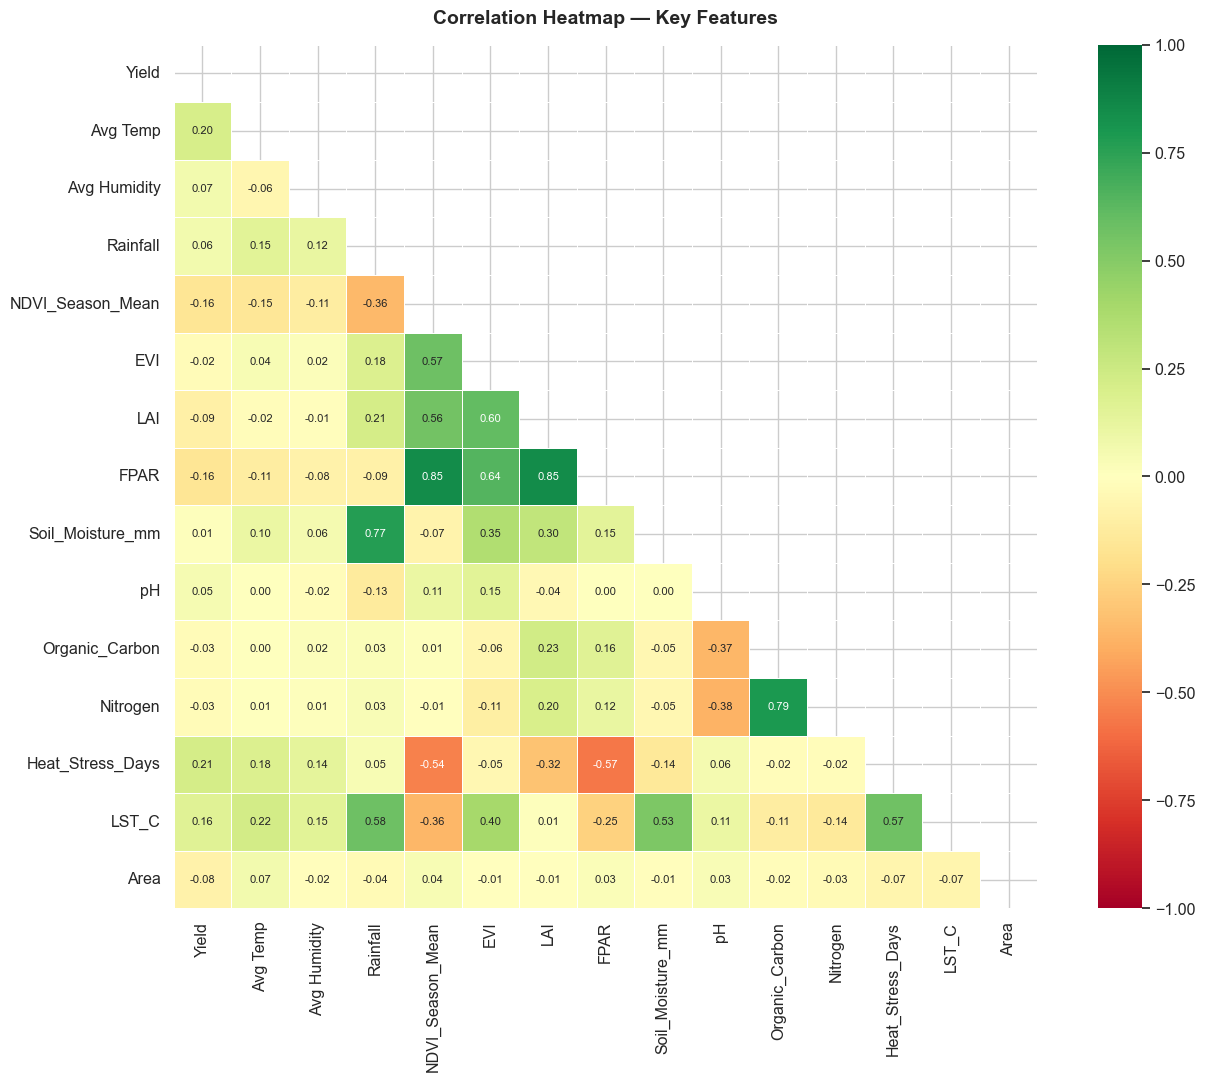

🔍 Key: NDVI_Season_Mean, EVI, and LAI show strong positive correlations — multicollinearity risk.


In [14]:
key_features = [
    'Yield','Avg Temp','Avg Humidity','Rainfall','NDVI_Season_Mean',
    'EVI','LAI','FPAR','Soil_Moisture_mm','pH','Organic_Carbon',
    'Nitrogen','Heat_Stress_Days','LST_C','Area'
]

corr_sub = df[key_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax, square=True)
ax.set_title('Correlation Heatmap — Key Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('🔍 Key: NDVI_Season_Mean, EVI, and LAI show strong positive correlations — multicollinearity risk.')


### 2.10 Outlier Analysis

In [15]:
key_num = ['Yield','Area','Production','Avg Temp','Rainfall','NDVI_Season_Mean',
           'Soil_Moisture_mm','pH','Organic_Carbon','Heat_Stress_Days']

outlier_summary = []
for col in key_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'Feature': col, 'Q1': round(Q1,3), 'Q3': round(Q3,3),
                            'IQR': round(IQR,3), 'Outliers': n_out,
                            'Outlier %': round(n_out/len(df)*100, 2)})

out_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
print('🔎 Outlier Summary (IQR Method):')
out_df.style.background_gradient(subset=['Outlier %'], cmap='YlOrRd').format({'Outlier %': '{:.2f}%'})


🔎 Outlier Summary (IQR Method):


,Feature,Q1,Q3,IQR,Outliers,Outlier %
1,Area,106.000000,949.750000,843.750000,619,14.82%
2,Production,233.000000,3389.750000,3156.750000,601,14.38%
0,Yield,1.286000,4.662000,3.376000,381,9.12%
5,NDVI_Season_Mean,0.306000,0.442000,0.136000,97,2.32%
4,Rainfall,158.440000,1238.150000,1079.710000,20,0.48%
3,Avg Temp,20.000000,27.500000,7.500000,0,0.00%
6,Soil_Moisture_mm,12.158000,25.296000,13.138000,0,0.00%
7,pH,5.640000,5.990000,0.350000,0,0.00%
8,Organic_Carbon,17.040000,23.440000,6.400000,0,0.00%
9,Heat_Stress_Days,0.000000,17.000000,17.000000,0,0.00%


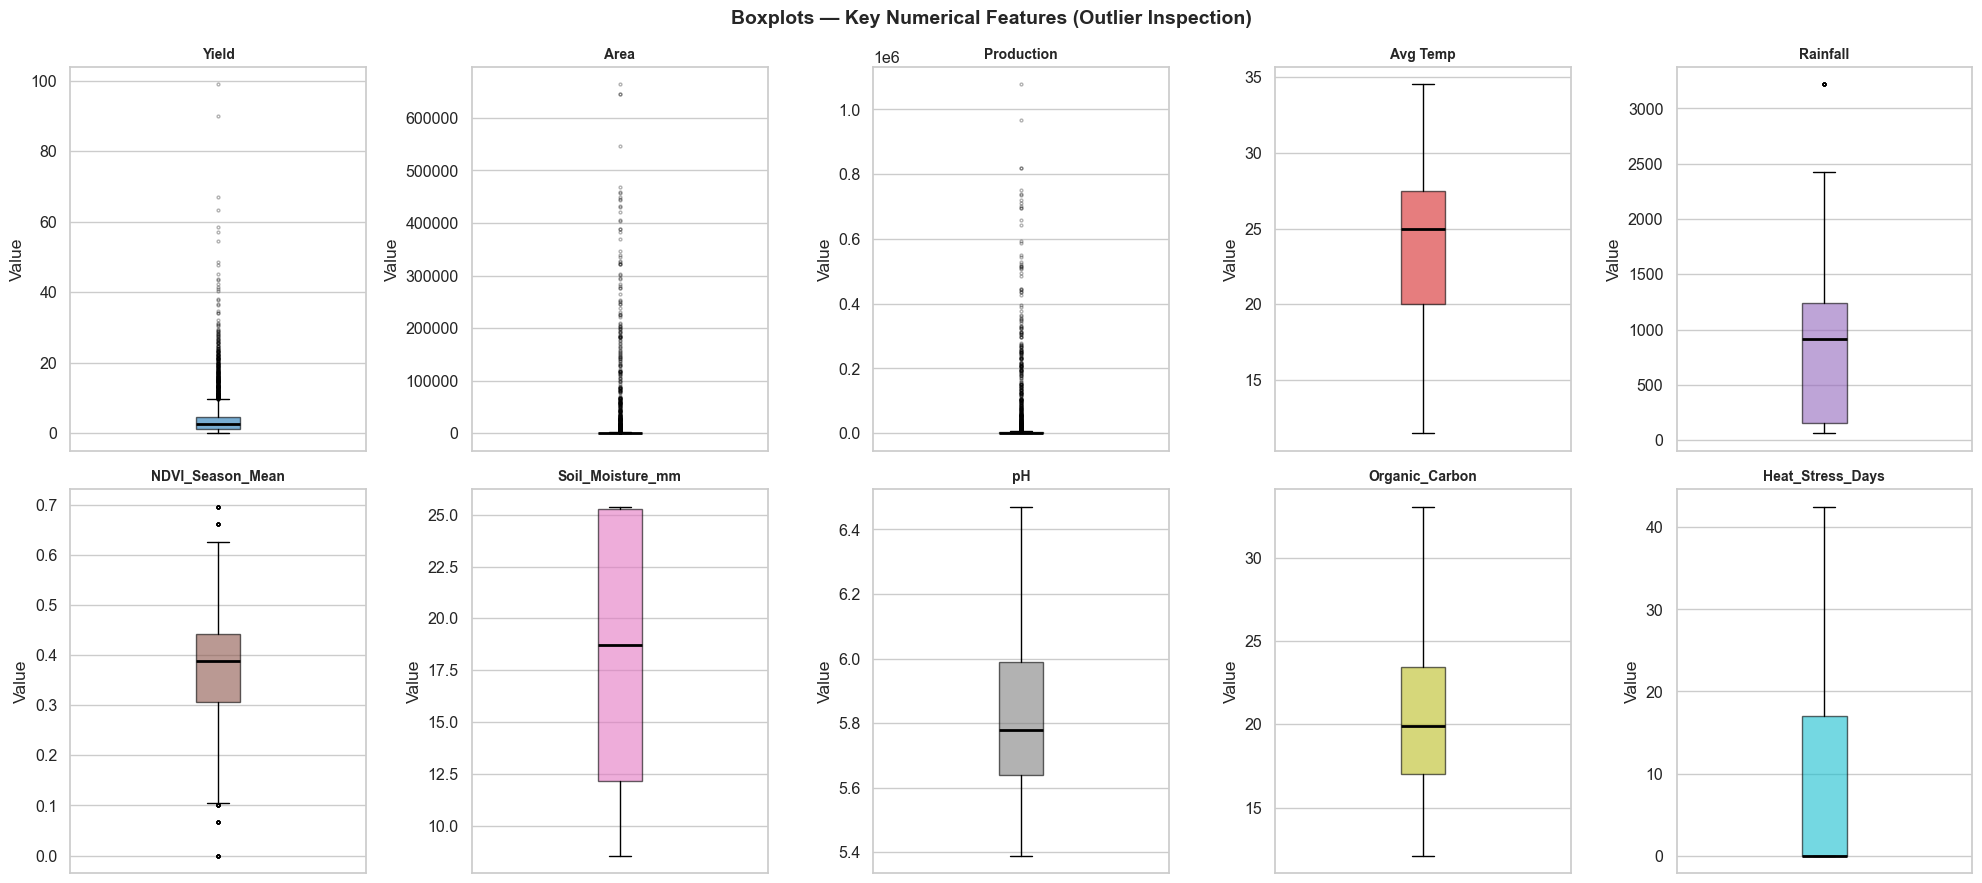

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('Boxplots — Key Numerical Features (Outlier Inspection)', fontsize=14, fontweight='bold')
axes = axes.flatten()

colors_box = plt.cm.tab10.colors
for i, col in enumerate(key_num):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colors_box[i], alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3, color=colors_box[i]))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.11 District-level Yield Heatmap (Top 20 Districts)

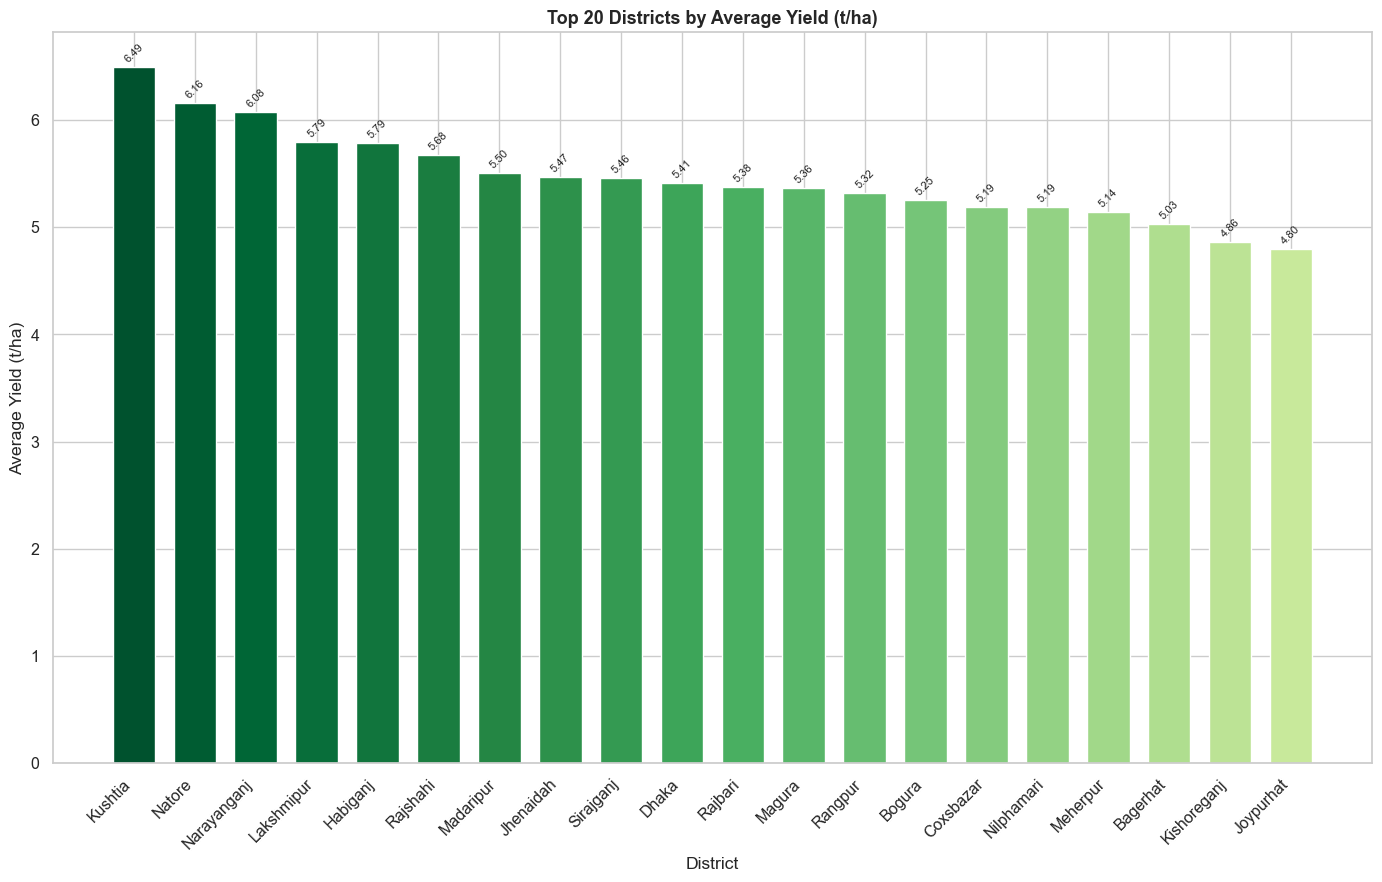

In [17]:
district_yield = df.groupby('District')['Yield'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 9))
colors = plt.cm.YlGn(np.linspace(0.3, 0.95, 20))
bars = ax.bar(district_yield.head(20).index, district_yield.head(20).values,
              color=colors[::-1], edgecolor='white', width=0.7)
ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=8, rotation=45)
ax.set_title('Top 20 Districts by Average Yield (t/ha)', fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Average Yield (t/ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('district_yield.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.12 Feature Group Analysis

In [18]:
# NDVI features
ndvi_cols = [c for c in df.columns if 'NDVI' in c]
print('NDVI Feature Correlation with Yield:')
print(df[ndvi_cols + ['Yield']].corr()['Yield'].drop('Yield').sort_values(ascending=False))

# Soil features
soil_cols = ['pH','Organic_Carbon','Nitrogen','Clay','Sand','Silt','Bulk_Density','CN_Ratio','Avg_Salinity_Index']
print('\nSoil Feature Correlation with Yield:')
print(df[soil_cols + ['Yield']].corr()['Yield'].drop('Yield').sort_values(ascending=False))

# Climate features
climate_cols = ['Avg Temp','Max Temp','Min Temp','Rainfall','Heat_Stress_Days','LST_C','Wind_Mean','Wind_Max']
print('\nClimate Feature Correlation with Yield:')
print(df[climate_cols + ['Yield']].corr()['Yield'].drop('Yield').sort_values(ascending=False))


NDVI Feature Correlation with Yield:
NDVI_Season_CV       0.0285
NDVI_Season_Range   -0.0575
NDVI_Season_Std     -0.0652
NDVI_Season_Min     -0.1095
NDVI_Season_Max     -0.1476
NDVI_Season_Mean    -0.1563
Name: Yield, dtype: float64

Soil Feature Correlation with Yield:
Avg_Salinity_Index    0.1597
Clay                  0.0640
pH                    0.0546
Bulk_Density          0.0273
CN_Ratio              0.0143
Silt                  0.0073
Organic_Carbon       -0.0252
Nitrogen             -0.0268
Sand                 -0.0488
Name: Yield, dtype: float64

Climate Feature Correlation with Yield:
Heat_Stress_Days   0.2149
Avg Temp           0.2047
Min Temp           0.1821
LST_C              0.1620
Max Temp           0.1586
Wind_Mean          0.1212
Wind_Max           0.0636
Rainfall           0.0632
Name: Yield, dtype: float64


### 2.13 Crop × Season Distribution (Crosstab)


📊 Crop × Season Record Count:
Season        Kharif 1  Kharif 2  Rabi
Crop Name                             
Aman                 0        64     0
Amra                64         0     0
Arhar                0        33     0
Aus                 64         0     0
Banana               0         0    64
...                ...       ...   ...
Sweet Potato         0         0    64
Taramind            63         0     0
Tobacco              0        24     0
Wheat                0         0    57
Wood Apple          64         0     0

[72 rows x 3 columns]


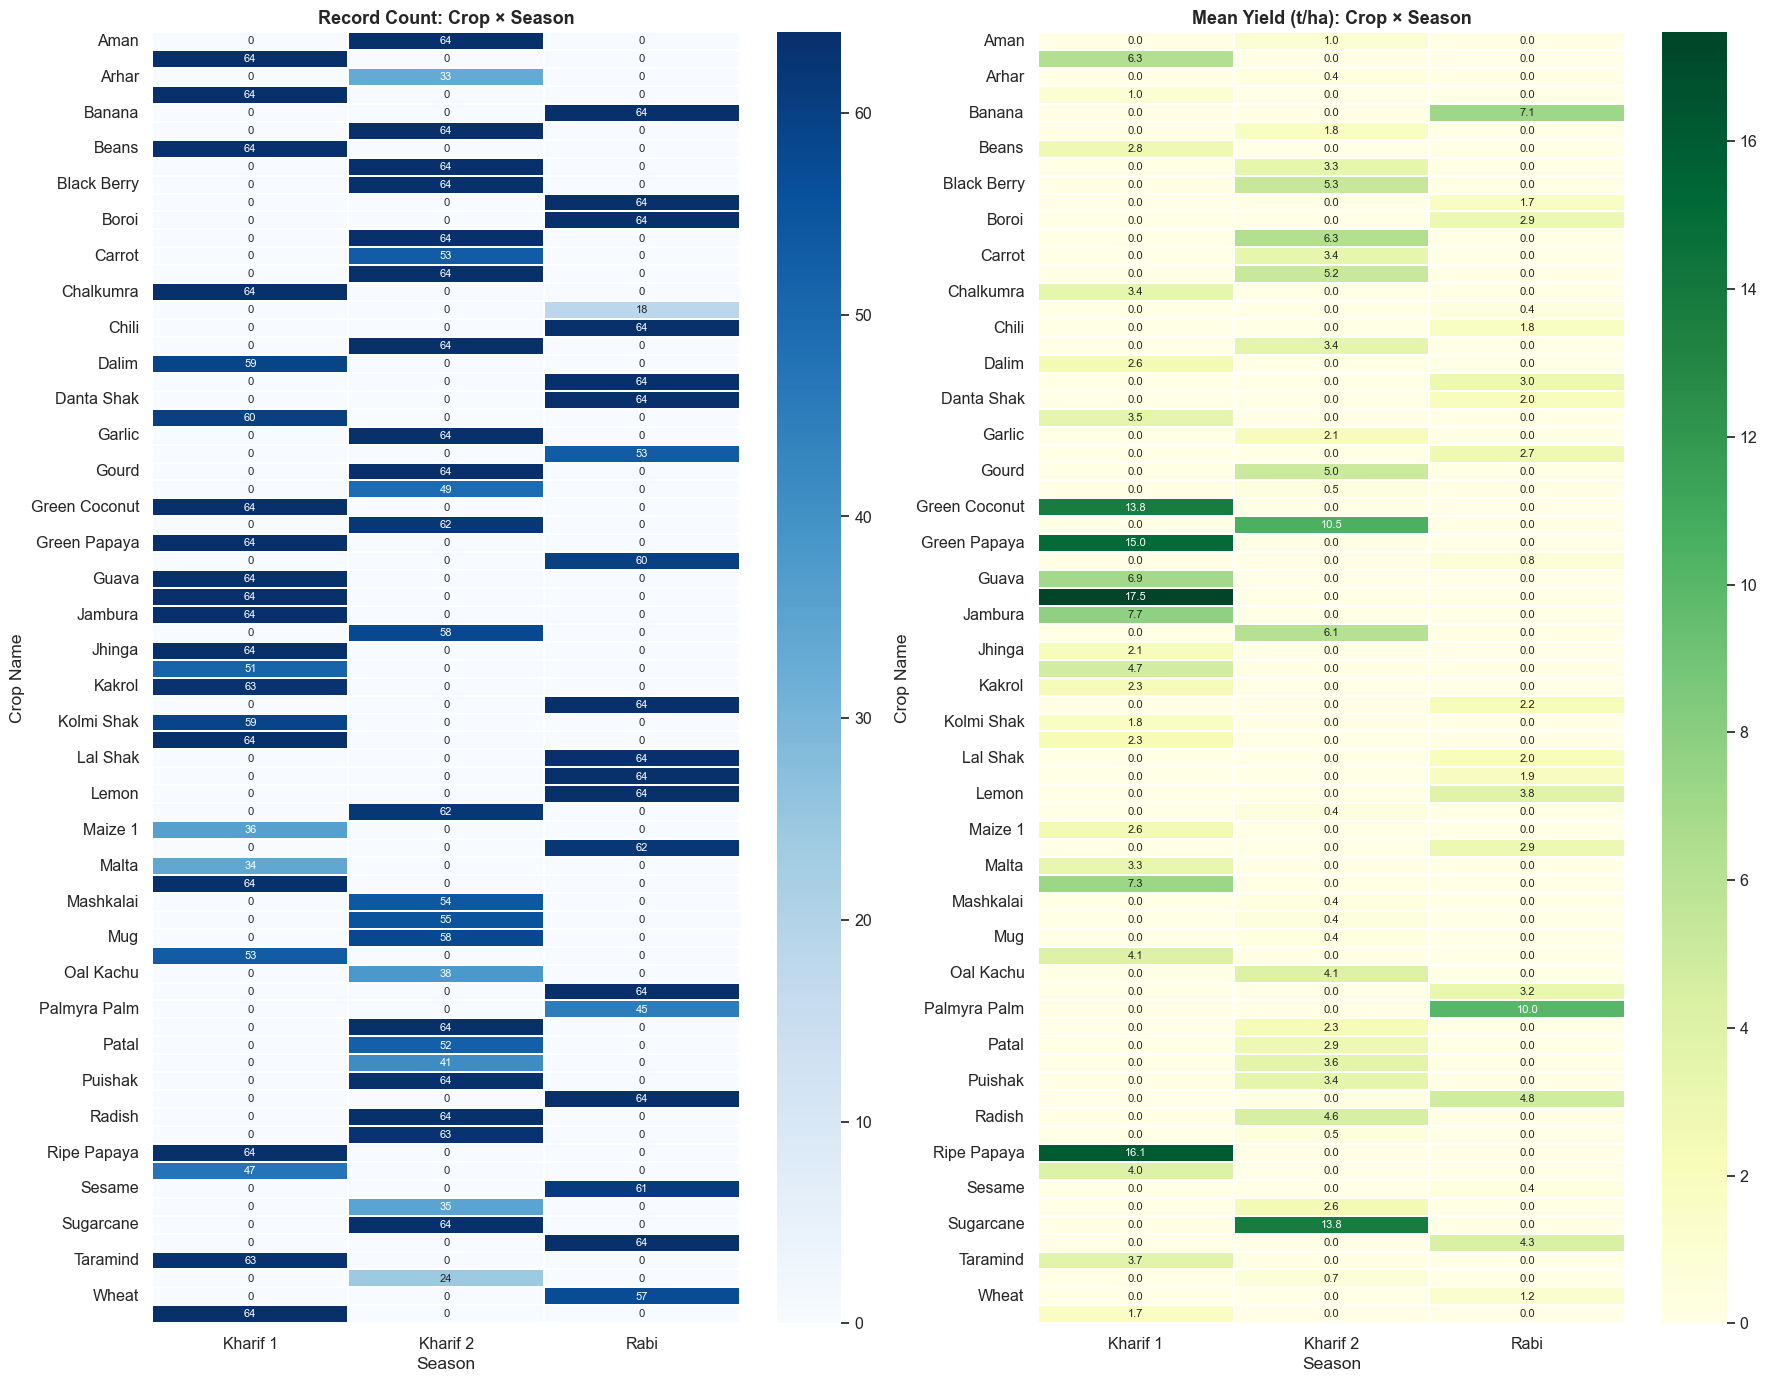

In [19]:
# Crop × Season record count
crop_season_ct = pd.crosstab(df['Crop Name'], df['Season'])
print('📊 Crop × Season Record Count:')
print(crop_season_ct)

# Heatmap of crop × season mean yield
crop_season_yield = df.groupby(['Crop Name','Season'])['Yield'].mean().unstack('Season').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 14))

# Count heatmap
sns.heatmap(crop_season_ct, annot=True, fmt='d', cmap='Blues',
            linewidths=0.3, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Record Count: Crop × Season', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Crop Name')

# Mean yield heatmap
sns.heatmap(crop_season_yield, annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.3, ax=axes[1], annot_kws={'size': 8})
axes[1].set_title('Mean Yield (t/ha): Crop × Season', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Crop Name')

plt.tight_layout()
plt.savefig('crop_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.14 Water Availability & Salinity Analysis

💧 Yield by Water Availability Category:
                         Mean  Median    Std  Count
Water_Availability_Cat                             
Moderate               4.4890  2.6610 6.0800   1171
Optimal                4.0580  2.4580 5.6470   3007


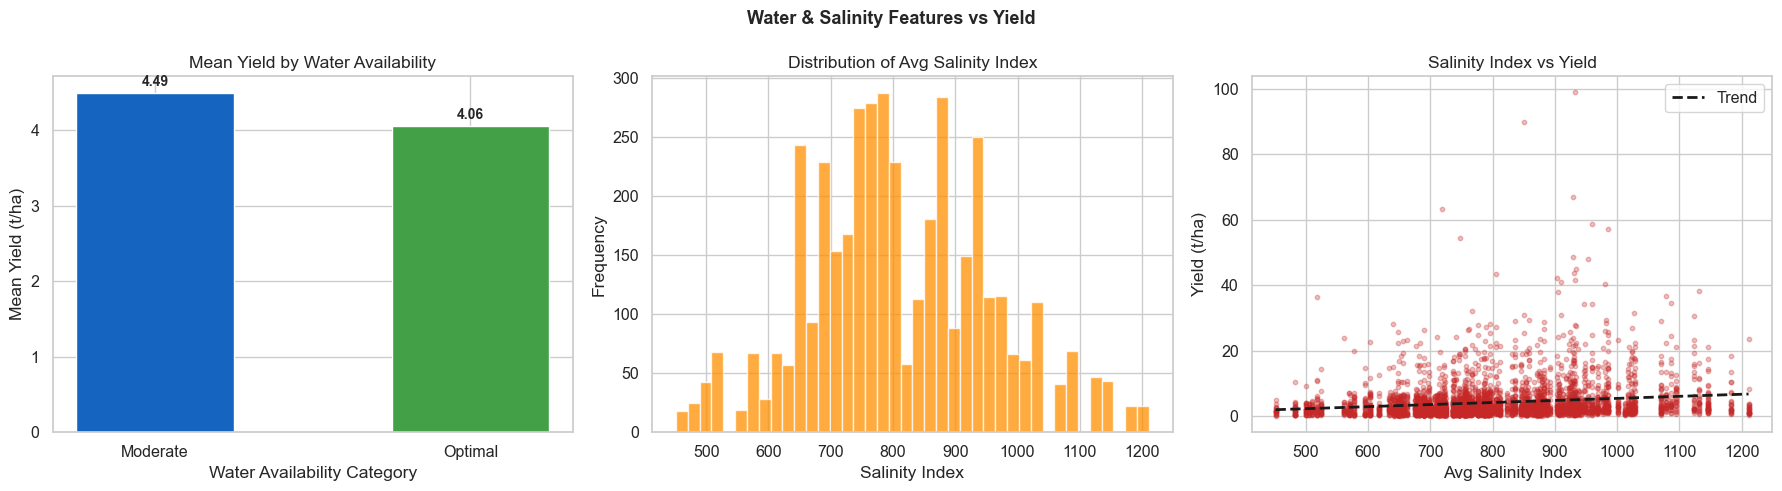

In [20]:
# Water availability category vs yield
water_stats = df.groupby('Water_Availability_Cat')['Yield'].agg(['mean','median','std','count']).round(3)
water_stats.columns = ['Mean','Median','Std','Count']
print('💧 Yield by Water Availability Category:')
print(water_stats)

# Salinity index distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Water & Salinity Features vs Yield', fontsize=13, fontweight='bold')

# Water availability bar chart
colors_w = ['#1565C0','#43A047','#E65100']
bars = axes[0].bar(water_stats.index, water_stats['Mean'],
                   color=colors_w[:len(water_stats)], edgecolor='white', width=0.5)
axes[0].bar_label(bars, fmt='%.2f', padding=3, fontsize=10, fontweight='bold')
axes[0].set_title('Mean Yield by Water Availability')
axes[0].set_ylabel('Mean Yield (t/ha)')
axes[0].set_xlabel('Water Availability Category')

# Salinity index histogram
axes[1].hist(df['Avg_Salinity_Index'], bins=40, color='#FF8F00', alpha=0.75, edgecolor='white')
axes[1].set_title('Distribution of Avg Salinity Index')
axes[1].set_xlabel('Salinity Index')
axes[1].set_ylabel('Frequency')

# Salinity vs yield scatter
axes[2].scatter(df['Avg_Salinity_Index'], df['Yield'], alpha=0.3, s=10, c='#C62828')
z = np.polyfit(df['Avg_Salinity_Index'], df['Yield'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Avg_Salinity_Index'].min(), df['Avg_Salinity_Index'].max(), 200)
axes[2].plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend')
axes[2].set_title('Salinity Index vs Yield')
axes[2].set_xlabel('Avg Salinity Index')
axes[2].set_ylabel('Yield (t/ha)')
axes[2].legend()

plt.tight_layout()
plt.savefig('water_salinity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.15 Soil Texture & pH Suitability Analysis

🌱 Soil Texture × pH Suitability Distribution:
pH_Suitability         Acidic  Optimal   All
Dominant_Soil_Texture                       
Clayey                     65        0    65
Loamy                     193     3920  4113
All                       258     3920  4178


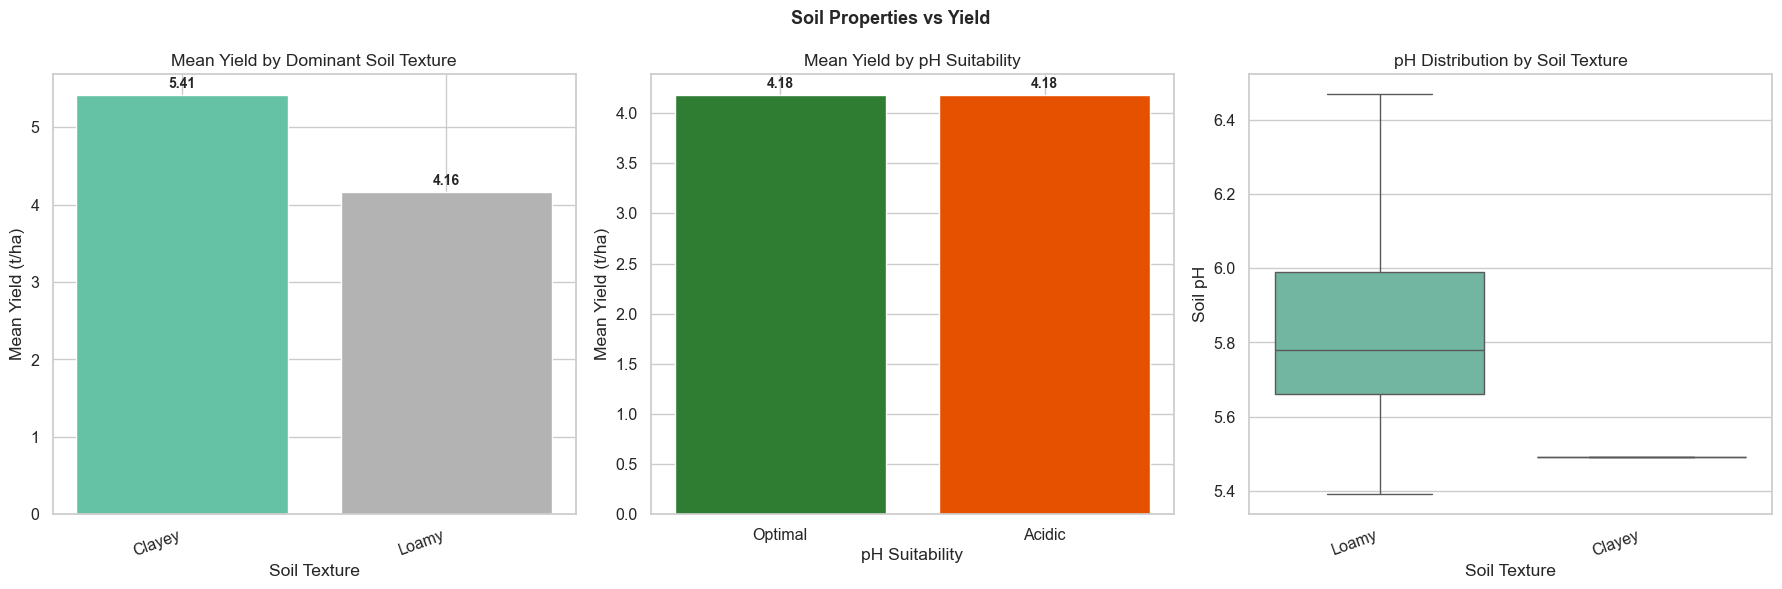

In [21]:
# Soil texture × pH suitability crosstab
print('🌱 Soil Texture × pH Suitability Distribution:')
soil_ct = pd.crosstab(df['Dominant_Soil_Texture'], df['pH_Suitability'], margins=True)
print(soil_ct)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Soil Properties vs Yield', fontsize=13, fontweight='bold')

# Mean yield by soil texture
soil_tex_yield = df.groupby('Dominant_Soil_Texture')['Yield'].mean().sort_values(ascending=False)
colors_st = plt.cm.Set2(np.linspace(0, 1, len(soil_tex_yield)))
bars = axes[0].bar(soil_tex_yield.index, soil_tex_yield.values, color=colors_st, edgecolor='white')
axes[0].bar_label(bars, fmt='%.2f', padding=3, fontsize=10, fontweight='bold')
axes[0].set_title('Mean Yield by Dominant Soil Texture')
axes[0].set_ylabel('Mean Yield (t/ha)')
axes[0].set_xlabel('Soil Texture')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Mean yield by pH suitability
ph_suit_yield = df.groupby('pH_Suitability')['Yield'].mean().sort_values(ascending=False)
colors_ph = ['#2E7D32','#E65100']
bars2 = axes[1].bar(ph_suit_yield.index, ph_suit_yield.values, color=colors_ph[:len(ph_suit_yield)], edgecolor='white')
axes[1].bar_label(bars2, fmt='%.2f', padding=3, fontsize=10, fontweight='bold')
axes[1].set_title('Mean Yield by pH Suitability')
axes[1].set_ylabel('Mean Yield (t/ha)')
axes[1].set_xlabel('pH Suitability')

# pH value distribution by texture
sns.boxplot(data=df, x='Dominant_Soil_Texture', y='pH', palette='Set2', ax=axes[2])
axes[2].set_title('pH Distribution by Soil Texture')
axes[2].set_xlabel('Soil Texture')
axes[2].set_ylabel('Soil pH')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig('soil_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.16 Wind & Extreme Weather Analysis

🌡️ Yield by Extreme Heat Risk:
                    mean  median    std  count
Extreme_Heat_Risk                             
High Risk         6.0680  3.1910 8.1330   1154
Low Risk          3.3310  2.2310 4.1230   2589
Moderate Risk     4.2130  2.5460 5.4770    435


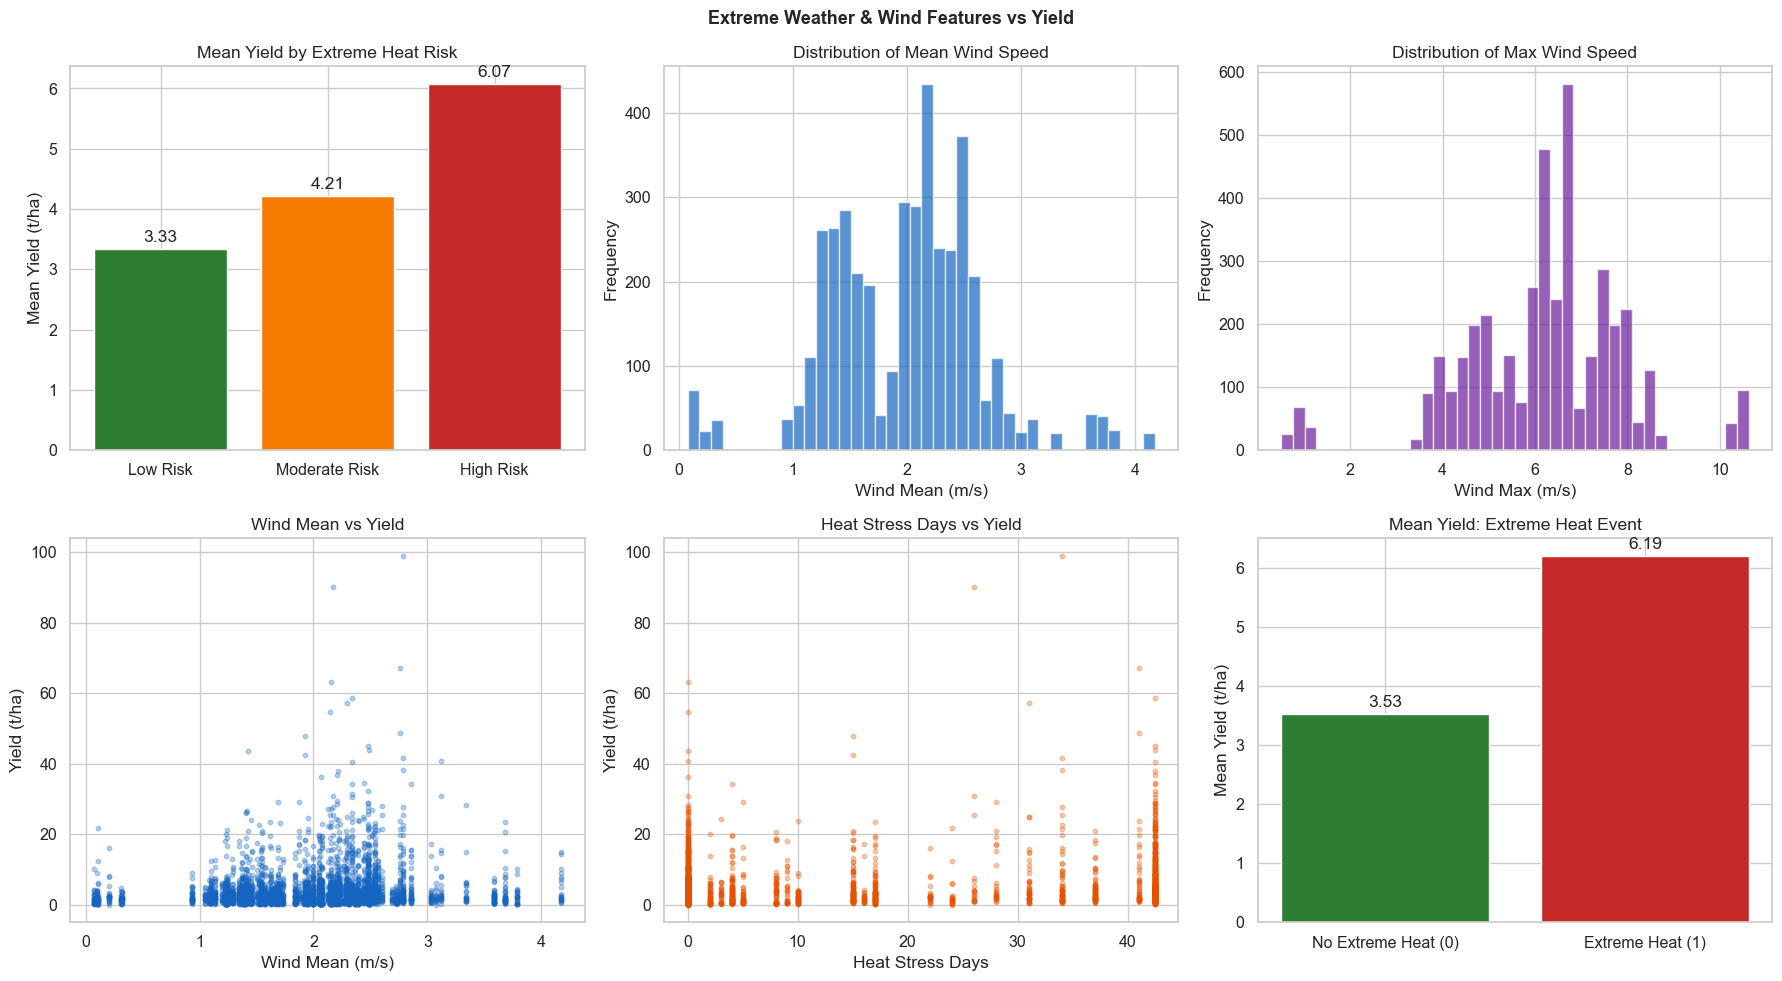

In [22]:
# Extreme heat risk vs yield
heat_stats = df.groupby('Extreme_Heat_Risk')['Yield'].agg(['mean','median','std','count']).round(3)
print('🌡️ Yield by Extreme Heat Risk:')
print(heat_stats)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Extreme Weather & Wind Features vs Yield', fontsize=13, fontweight='bold')

# Extreme heat risk bar chart
heat_order = ['Low Risk','Moderate Risk','High Risk']
heat_means = [df[df['Extreme_Heat_Risk']==r]['Yield'].mean() for r in heat_order if r in df['Extreme_Heat_Risk'].unique()]
heat_labels = [r for r in heat_order if r in df['Extreme_Heat_Risk'].unique()]
colors_heat = ['#2E7D32','#F57C00','#C62828'][:len(heat_labels)]
bars = axes[0,0].bar(heat_labels, heat_means, color=colors_heat, edgecolor='white')
axes[0,0].bar_label(bars, fmt='%.2f', padding=3)
axes[0,0].set_title('Mean Yield by Extreme Heat Risk')
axes[0,0].set_ylabel('Mean Yield (t/ha)')

# Wind Mean distribution
axes[0,1].hist(df['Wind_Mean'], bins=40, color='#1565C0', alpha=0.7, edgecolor='white')
axes[0,1].set_title('Distribution of Mean Wind Speed')
axes[0,1].set_xlabel('Wind Mean (m/s)')
axes[0,1].set_ylabel('Frequency')

# Wind Max distribution
axes[0,2].hist(df['Wind_Max'], bins=40, color='#6A1B9A', alpha=0.7, edgecolor='white')
axes[0,2].set_title('Distribution of Max Wind Speed')
axes[0,2].set_xlabel('Wind Max (m/s)')
axes[0,2].set_ylabel('Frequency')

# Wind Mean vs Yield
axes[1,0].scatter(df['Wind_Mean'], df['Yield'], alpha=0.3, s=10, c='#1565C0')
axes[1,0].set_title('Wind Mean vs Yield')
axes[1,0].set_xlabel('Wind Mean (m/s)')
axes[1,0].set_ylabel('Yield (t/ha)')

# Heat Stress Days vs Yield
axes[1,1].scatter(df['Heat_Stress_Days'], df['Yield'], alpha=0.3, s=10, c='#E65100')
axes[1,1].set_title('Heat Stress Days vs Yield')
axes[1,1].set_xlabel('Heat Stress Days')
axes[1,1].set_ylabel('Yield (t/ha)')

# Is_Extreme_Heat binary comparison
heat_binary = df.groupby('Is_Extreme_Heat')['Yield'].agg(['mean','std','count'])
labels_b = ['No Extreme Heat (0)', 'Extreme Heat (1)'][:len(heat_binary)]
bars_b = axes[1,2].bar(labels_b, heat_binary['mean'].values, color=['#2E7D32','#C62828'][:len(heat_binary)], edgecolor='white')
axes[1,2].bar_label(bars_b, fmt='%.2f', padding=3)
axes[1,2].set_title('Mean Yield: Extreme Heat Event')
axes[1,2].set_ylabel('Mean Yield (t/ha)')

plt.tight_layout()
plt.savefig('weather_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.17 Vegetation Index Deep-Dive

🌿 Vegetation Index Correlation with Yield:
NDVI_Season_CV       0.0285
EVI                 -0.0235
NDVI_Season_Range   -0.0575
NDVI_Season_Std     -0.0652
LAI                 -0.0948
NDVI_Season_Min     -0.1095
NDVI_Season_Max     -0.1476
NDVI_Season_Mean    -0.1563
FPAR                -0.1636


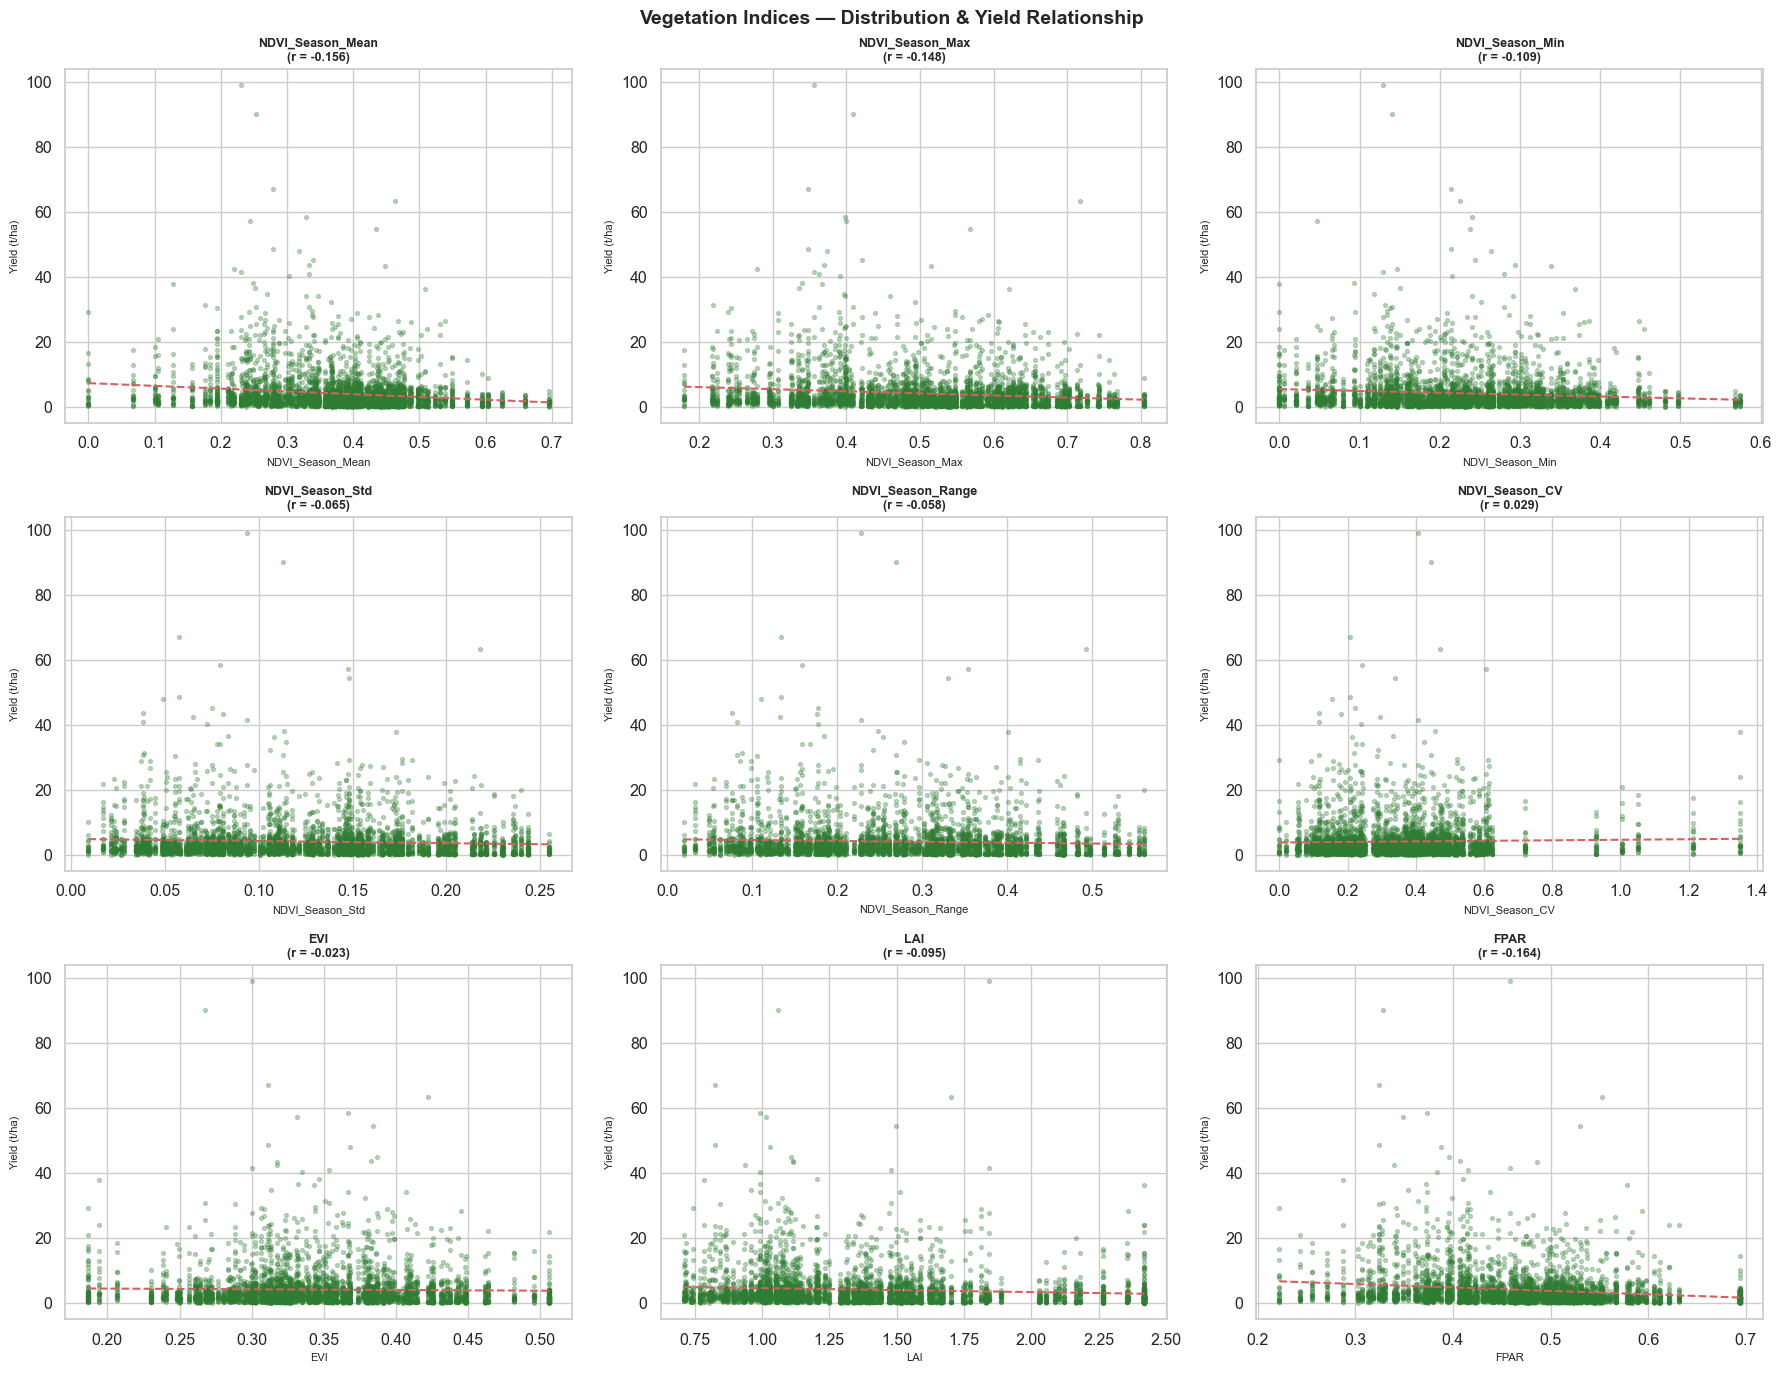

In [23]:
veg_cols = ['NDVI_Season_Mean','NDVI_Season_Max','NDVI_Season_Min','NDVI_Season_Std',
            'NDVI_Season_Range','NDVI_Season_CV','EVI','LAI','FPAR']

# Correlation table
veg_corr = df[veg_cols + ['Yield']].corr()['Yield'].drop('Yield').sort_values(ascending=False)
print('🌿 Vegetation Index Correlation with Yield:')
print(veg_corr.to_string())

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Vegetation Indices — Distribution & Yield Relationship', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(veg_cols):
    axes[i].scatter(df[col], df['Yield'], alpha=0.3, s=8, c='#2E7D32')
    # Trend line
    z = np.polyfit(df[col], df['Yield'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 200)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=1.5)
    r = df[[col,'Yield']].corr().iloc[0,1]
    axes[i].set_title(f'{col}\n(r = {r:.3f})', fontsize=9, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Yield (t/ha)', fontsize=8)

plt.tight_layout()
plt.savefig('vegetation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.18 Soil Composition Triangle Analysis

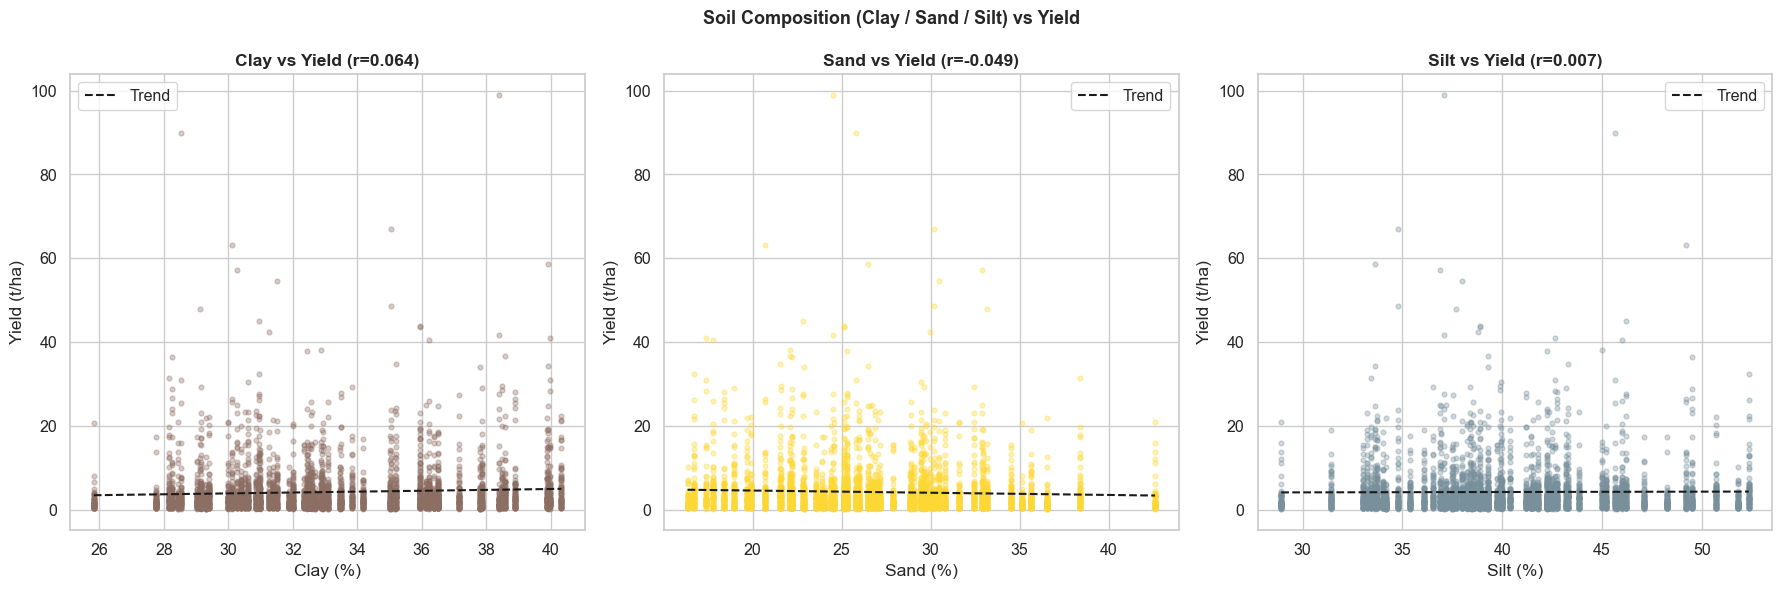


📊 Soil Composition Statistics:
           Clay      Sand      Silt  Organic_Carbon  Nitrogen  Bulk_Density
count 4178.0000 4178.0000 4178.0000       4178.0000 4178.0000     4178.0000
mean    33.1740   26.5990   40.2260         20.5450    1.9190        1.2860
std      3.5270    5.3680    5.0030          4.9920    0.5530        0.0270
min     25.8280   16.3320   28.9300         12.1200    1.2000        1.2200
25%     30.5180   22.8200   37.0660         17.0400    1.4900        1.2700
50%     32.5930   25.9700   39.2960         19.9100    1.8000        1.2900
75%     36.1330   29.7460   42.7240         23.4400    2.1800        1.3000
max     40.3340   42.6200   52.3500         33.0400    3.2150        1.3400


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Soil Composition (Clay / Sand / Silt) vs Yield', fontsize=13, fontweight='bold')

soil_components = ['Clay','Sand','Silt']
colors_soil = ['#8D6E63','#FDD835','#78909C']

for i, (comp, col) in enumerate(zip(soil_components, colors_soil)):
    sc = axes[i].scatter(df[comp], df['Yield'], alpha=0.35, s=12, c=col)
    z = np.polyfit(df[comp], df['Yield'], 1)
    p_line = np.poly1d(z)
    x_range = np.linspace(df[comp].min(), df[comp].max(), 200)
    axes[i].plot(x_range, p_line(x_range), 'k--', linewidth=1.5, label='Trend')
    r = df[[comp,'Yield']].corr().iloc[0,1]
    axes[i].set_title(f'{comp} vs Yield (r={r:.3f})', fontweight='bold')
    axes[i].set_xlabel(f'{comp} (%)')
    axes[i].set_ylabel('Yield (t/ha)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('soil_composition.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print('\n📊 Soil Composition Statistics:')
print(df[soil_components + ['Organic_Carbon','Nitrogen','Bulk_Density']].describe().round(3))


### 2.19 Rainfall & Temperature Interaction

🌧️ Rain-Temp Ratio Statistics:
count   4178.0000
mean      31.1320
std       21.4180
min        3.5000
25%        7.9900
50%       32.7000
75%       44.6700
max      120.0100
Name: Rain_Temp_Ratio, dtype: float64

Yield by Rain-Temp Ratio Quintile:
               Mean  Median  Count
RainTemp_bin                      
Very Low     3.0920  2.2550    883
Low          4.7210  2.7070    804
Medium       5.1110  2.9760    842
High         3.9580  2.3720    814
Very High    4.0810  2.4030    835


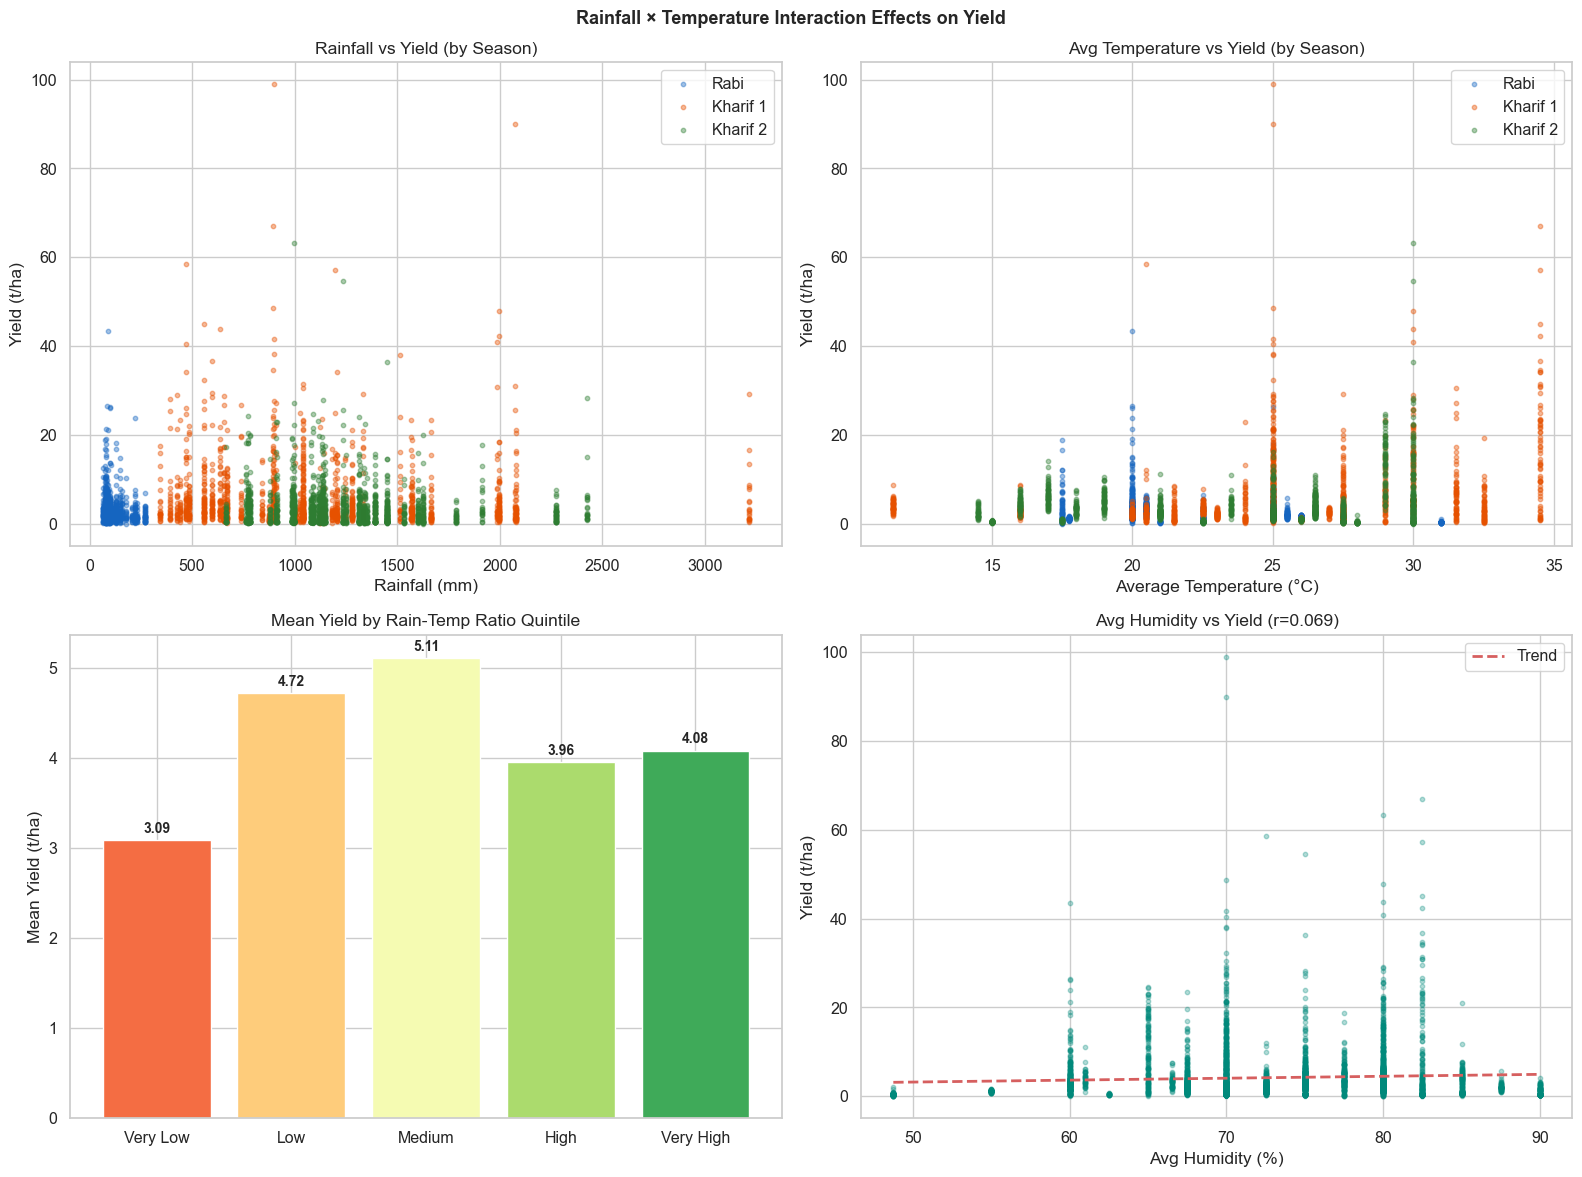

In [25]:
# Rain-Temp Ratio analysis
print('🌧️ Rain-Temp Ratio Statistics:')
print(df['Rain_Temp_Ratio'].describe().round(3))

# Bin rain-temp ratio
df['RainTemp_bin'] = pd.qcut(df['Rain_Temp_Ratio'], q=5, labels=['Very Low','Low','Medium','High','Very High'])

rtr_stats = df.groupby('RainTemp_bin', observed=True)['Yield'].agg(['mean','median','count']).round(3)
rtr_stats.columns = ['Mean','Median','Count']
print('\nYield by Rain-Temp Ratio Quintile:')
print(rtr_stats)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Rainfall × Temperature Interaction Effects on Yield', fontsize=13, fontweight='bold')

# Rainfall vs yield, coloured by season
season_palette = {'Rabi': '#1565C0', 'Kharif 1': '#E65100', 'Kharif 2': '#2E7D32'}
for season, color in season_palette.items():
    sub = df[df['Season'] == season]
    axes[0,0].scatter(sub['Rainfall'], sub['Yield'], alpha=0.4, s=10, color=color, label=season)
axes[0,0].set_title('Rainfall vs Yield (by Season)')
axes[0,0].set_xlabel('Rainfall (mm)')
axes[0,0].set_ylabel('Yield (t/ha)')
axes[0,0].legend()

# Avg Temp vs yield, coloured by season
for season, color in season_palette.items():
    sub = df[df['Season'] == season]
    axes[0,1].scatter(sub['Avg Temp'], sub['Yield'], alpha=0.4, s=10, color=color, label=season)
axes[0,1].set_title('Avg Temperature vs Yield (by Season)')
axes[0,1].set_xlabel('Average Temperature (°C)')
axes[0,1].set_ylabel('Yield (t/ha)')
axes[0,1].legend()

# Rain-Temp ratio quintile bars
bars = axes[1,0].bar(rtr_stats.index, rtr_stats['Mean'],
                     color=plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(rtr_stats))),
                     edgecolor='white')
axes[1,0].bar_label(bars, fmt='%.2f', padding=3, fontsize=10, fontweight='bold')
axes[1,0].set_title('Mean Yield by Rain-Temp Ratio Quintile')
axes[1,0].set_ylabel('Mean Yield (t/ha)')

# Humidity vs yield
axes[1,1].scatter(df['Avg Humidity'], df['Yield'], alpha=0.3, s=10, c='#00897B')
z = np.polyfit(df['Avg Humidity'], df['Yield'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Avg Humidity'].min(), df['Avg Humidity'].max(), 200)
axes[1,1].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
r = df[['Avg Humidity','Yield']].corr().iloc[0,1]
axes[1,1].set_title(f'Avg Humidity vs Yield (r={r:.3f})')
axes[1,1].set_xlabel('Avg Humidity (%)')
axes[1,1].set_ylabel('Yield (t/ha)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('rainfall_temp_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['RainTemp_bin'], inplace=True)


### 2.20 District-level Complete Analysis (All 64 Districts)

📍 All 64 Districts — Yield Statistics:
                  Mean Yield  Median  Std Dev  Records
District                                              
Kushtia               6.4950  4.0390   8.2000       67
Natore                6.1580  3.2490   9.1060       68
Narayanganj           6.0770  2.3710  10.7790       66
Lakshmipur            5.7900  1.8810  14.2060       61
Habiganj              5.7860  2.7930  12.9040       54
Rajshahi              5.6770  3.9020   6.6350       68
Madaripur             5.5030  4.1220   7.5330       63
Jhenaidah             5.4660  3.4650   6.1620       70
Sirajganj             5.4600  3.1340   6.2590       68
Dhaka                 5.4130  3.5850   5.4880       65
Rajbari               5.3780  3.6870   7.4010       68
Magura                5.3610  3.2940   8.7500       67
Rangpur               5.3230  2.6190   8.3130       69
Bogura                5.2530  3.3410   6.1660       69
Coxsbazar             5.1920  2.4120   7.6170       57
Nilphamari            5.18

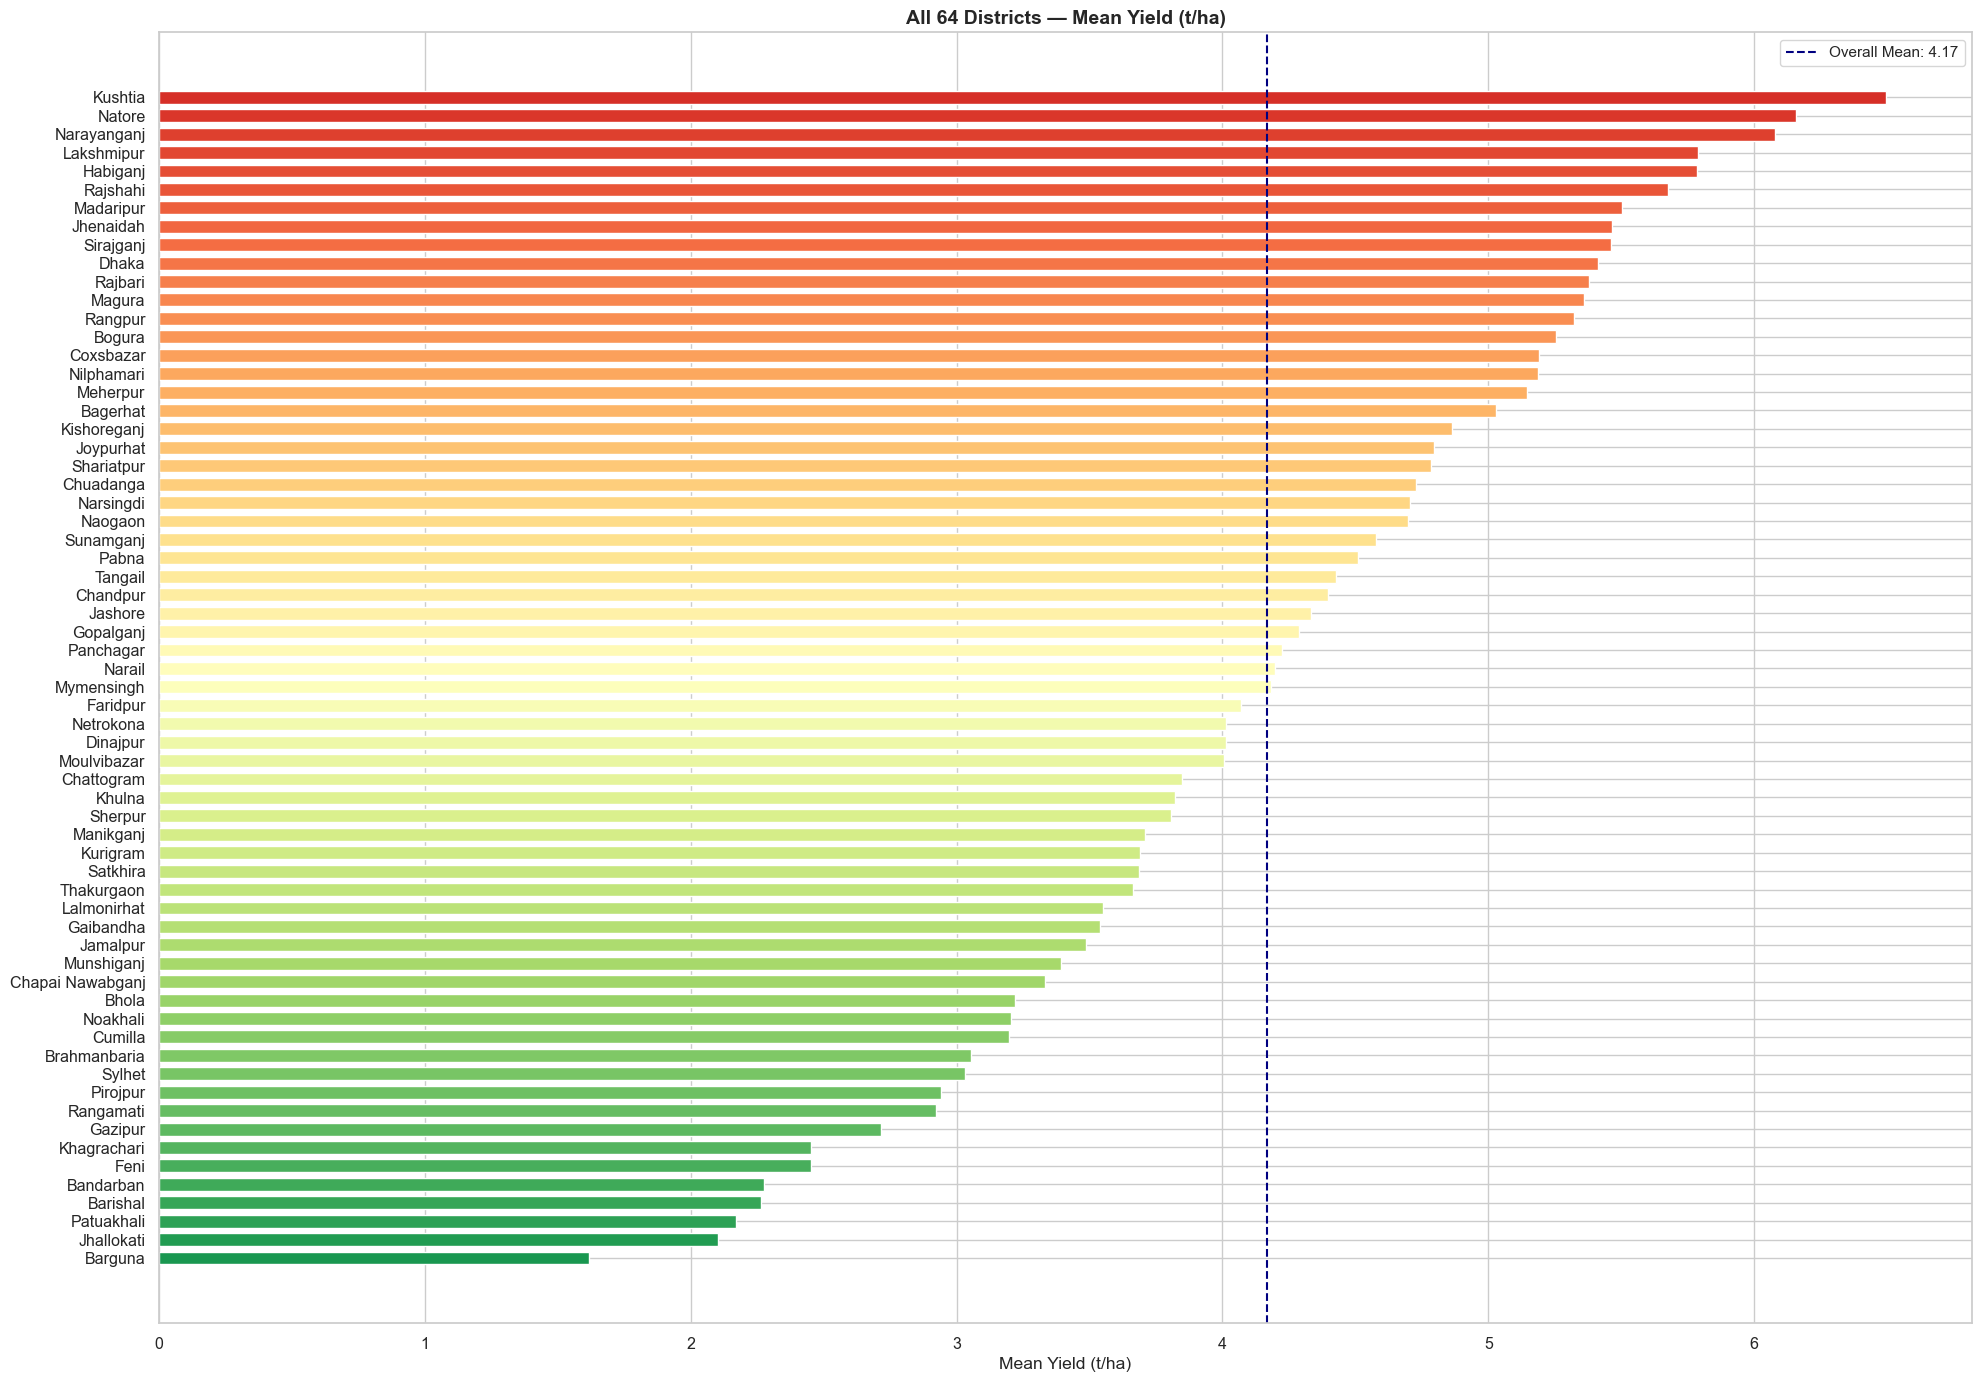

In [26]:
district_full = df.groupby('District')['Yield'].agg(['mean','median','std','count']).round(3)
district_full.columns = ['Mean Yield','Median','Std Dev','Records']
district_full = district_full.sort_values('Mean Yield', ascending=False)

print(f'📍 All {len(district_full)} Districts — Yield Statistics:')
print(district_full.to_string())

# Full district bar chart
fig, ax = plt.subplots(figsize=(20, 14))
colors_d = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(district_full)))
bars = ax.barh(district_full.index, district_full['Mean Yield'],
               color=colors_d, edgecolor='white', height=0.7)
ax.axvline(district_full['Mean Yield'].mean(), color='navy', linestyle='--',
           linewidth=1.5, label=f"Overall Mean: {district_full['Mean Yield'].mean():.2f}")
ax.set_title('All 64 Districts — Mean Yield (t/ha)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Yield (t/ha)')
ax.invert_yaxis()
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('district_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.21 Initial Key Observations & Summary


In [27]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║          📋 EDA SUMMARY — KEY INITIAL OBSERVATIONS                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  DATASET                                                             ║
║  • 4,178 cleaned records, 51 features (Agri_Data_Cleaned.csv)        ║
║  • 72 unique crops across 64 Bangladesh districts, 3 seasons         ║
║  • ZERO missing values — dataset is complete                         ║
║                                                                      ║
║  TARGET VARIABLE (Yield)                                             ║
║  • Highly right-skewed — log transform recommended                   ║
║  • ~8% outliers by IQR method (extreme yields for special crops)     ║
║                                                                      ║
║  TOP PREDICTORS (Pearson corr with Yield)                            ║
║  • Vegetation: NDVI_Mean, EVI, LAI, FPAR                             ║
║  • Soil: Organic_Carbon, Nitrogen, pH                                ║
║  • Climate: Rainfall, Avg Humidity, Min Temp                         ║
║                                                                      ║
║  IMPORTANT PATTERNS                                                  ║
║  • Rabi season = highest median yield (cool/dry crops)               ║
║  • NDVI/EVI/LAI inter-correlated → multicollinearity risk            ║
║  • Crop type is the dominant categorical predictor                   ║
║  • Optimal water availability → significantly higher yield           ║
║  • High salinity negatively impacts yield                            ║
║  • Loamy soil texture associated with best yield outcomes            ║
║                                                                      ║
║  PREPROCESSING RECOMMENDATIONS                                       ║
║  • Log-transform Yield (skew correction)                             ║
║  • Encode: Crop Name, Season, District, pH_Suitability, etc.         ║
║  • Scale/normalize numerical features                                ║
║  • Consider PCA on correlated vegetation indices                     ║
╚══════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════╗
║          📋 EDA SUMMARY — KEY INITIAL OBSERVATIONS                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  DATASET                                                             ║
║  • 4,178 cleaned records, 51 features (Agri_Data_Cleaned.csv)        ║
║  • 72 unique crops across 64 Bangladesh districts, 3 seasons         ║
║  • ZERO missing values — dataset is complete                         ║
║                                                                      ║
║  TARGET VARIABLE (Yield)                                             ║
║  • Highly right-skewed — log transform recommended                   ║
║  • ~8% outliers by IQR method (extreme yields for special crops)     ║
║                                                                      ║
║  TOP PREDICTORS (Pearson corr with Yield)         